In [1]:

# 1) Imports des bibliothèques
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt 
import plotly.graph_objects as go
import plotly.express as px

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import seaborn as sns
import matplotlib.dates as mdates

import time
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("TF:", tf.__version__, "Keras:", keras.__version__)

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.3

TF: 2.20.0 Keras: 3.11.2


In [20]:
DATA_PATH = './Version_3_iot_telemetry_data/Version_3_iot_telemetry_data.csv' 

In [21]:
# Hyperparamètres
LOOK_BACK = 24            # 24 pas passés (ex: 24 h)
FORECAST_HORIZON = 6      # 6 pas futurs à prédire (ex: 6 h)
TARGET_COLS = ['temp','humidity','co','lpg']
TIME_FEATS = ['hour','day_of_week','month','weekend_flag']

BATCH_SIZE = 32
EPOCHS = 100
PATIENCE_ES = 10
PATIENCE_RLR = 5
LR_FACTOR = 0.5

OUT_DIR = Path('./Version_4_artifacts')
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = OUT_DIR / 'Version_4_models'
SCALERS_DIR = OUT_DIR / 'Version_4s_scalers'
MODEL_DIR.mkdir(exist_ok=True)
SCALERS_DIR.mkdir(exist_ok=True)

BEST_MODEL_PATH = str(MODEL_DIR / 'Version_4_best_model.keras')
FINAL_MODEL_PATH = str(MODEL_DIR / 'Version_4_final_model.keras')
TFLITE_PATH = str(MODEL_DIR / 'Version_4_model_multi_step.tflite')


### Justification des Hyperparamètres

In [59]:
print("\n--- Justification des Choix des Paramètres ---")
print(f"Horizon passé ({LOOK_BACK} pas): On analyse les 24 dernières heures pour capter le cycle complet d'une journée.")
print(f"Horizon futur ({FORECAST_HORIZON} pas): On veut prédire 6 heures à l'avance pour pouvoir anticiper les problèmes (anomalies).")
print(f"Cibles ({len(TARGET_COLS)} variables): On se concentre sur les données les plus importantes pour la sécurité : température, humidité, CO et LPG.")
print(f"Infos temps ajoutées: On donne au modèle l'heure et le jour (semaine/weekend) pour qu'il comprenne mieux les variations régulières.")
print(f"Taille de lot ({BATCH_SIZE}): C'est une taille habituelle qui permet au modèle d'apprendre vite sans perdre en précision.")
print(f"Patience arrêt précoce ({PATIENCE_ES}): Fixée à 10 pour laisser au modèle le temps de s'améliorer (éviter de s'arrêter trop tôt).")
print("Critère d'arrêt: On utilise la MSE (val_loss) sur le jeu de validation. Le modèle s'arrête quand il ne s'améliore plus sur les données non vues.")
print("-" * 40)


--- Justification des Choix des Paramètres ---
Horizon passé (24 pas): On analyse les 24 dernières heures pour capter le cycle complet d'une journée.
Horizon futur (6 pas): On veut prédire 6 heures à l'avance pour pouvoir anticiper les problèmes (anomalies).
Cibles (4 variables): On se concentre sur les données les plus importantes pour la sécurité : température, humidité, CO et LPG.
Infos temps ajoutées: On donne au modèle l'heure et le jour (semaine/weekend) pour qu'il comprenne mieux les variations régulières.
Taille de lot (32): C'est une taille habituelle qui permet au modèle d'apprendre vite sans perdre en précision.
Patience arrêt précoce (10): Fixée à 10 pour laisser au modèle le temps de s'améliorer (éviter de s'arrêter trop tôt).
Critère d'arrêt: On utilise la MSE (val_loss) sur le jeu de validation. Le modèle s'arrête quand il ne s'améliore plus sur les données non vues.
----------------------------------------


In [23]:
# 2) Chargement du dataset & préparation
DATA_PATH
assert os.path.exists(DATA_PATH), f"Fichier introuvable: {DATA_PATH}"

df_raw = pd.read_csv(DATA_PATH)
print("Colonnes détectées:", df_raw.columns.tolist())

# Conversion ts: souvent au format scientifique de timestamp UNIX en secondes
# -> numeric -> datetime (unit='s') puis index temporel
assert 'ts' in df_raw.columns, "Colonne 'ts' absente"
df_raw['ts'] = pd.to_datetime(pd.to_numeric(df_raw['ts'], errors='coerce'), unit='s')
df = df_raw.dropna(subset=['ts']).sort_values('ts').copy()
df.set_index('ts', inplace=True)

# Casting des cibles en float (au cas où elles sont strings)
for col in TARGET_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Taille après tri & index:", df.shape)
print(df[TARGET_COLS].head())

Colonnes détectées: ['ts', 'device', 'co', 'humidity', 'light', 'lpg', 'motion', 'smoke', 'temp']
Taille après tri & index: (405184, 8)
                                    temp   humidity        co       lpg
ts                                                                     
2020-07-12 00:01:34.385974646  22.700000  51.000000  0.004956  0.007651
2020-07-12 00:01:34.735567570  19.700001  76.000000  0.002840  0.005114
2020-07-12 00:01:38.073572874  22.600000  50.900000  0.004976  0.007673
2020-07-12 00:01:39.589145899  27.000000  76.800003  0.004403  0.007023
2020-07-12 00:01:41.761234999  22.600000  50.900000  0.004967  0.007664


In [24]:
# 3) Feature engineering temporel
# =====================================
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['weekend_flag'] = df.index.dayofweek.isin([5,6]).astype(int)
print("Features temporelles ajoutées:", TIME_FEATS)

Features temporelles ajoutées: ['hour', 'day_of_week', 'month', 'weekend_flag']


In [25]:
# 4) Gestion des NaN & anomalies simples
# ============================================
# Interpolation linéaire + backward fill (bfill) comme demandé
nans_before = df.isna().sum().sum()
df = df.interpolate(method='linear', limit_direction='both')
df = df.bfill()
nans_after = df.isna().sum().sum()
print(f"NaN avant: {nans_before}, après interpolation+bfill: {nans_after}")

# Clamp léger de sûreté (optionnel)
if 'temp' in df.columns:
    df['temp'] = df['temp'].clip(-40, 80)
if 'humidity' in df.columns:
    df['humidity'] = df['humidity'].clip(0, 100)


NaN avant: 0, après interpolation+bfill: 0


C:\Users\Macky\AppData\Local\Temp\ipykernel_18400\1863139166.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit_direction='both')


### Normalisation (MinMax)
### On garde **uniquement** les features numériques utiles

In [26]:

feature_cols = [c for c in TARGET_COLS] + TIME_FEATS
print("Features utilisées pour le modèle:", feature_cols)

scaler_all = MinMaxScaler()
X_all_scaled = scaler_all.fit_transform(df[feature_cols].astype(float).values)

# Scaler pour (uniquement) les 4 cibles
scaler_y = MinMaxScaler()
Y_all_scaled = scaler_y.fit_transform(df[TARGET_COLS].astype(float).values)

print("X_all_scaled:", X_all_scaled.shape, "Y_all_scaled:", Y_all_scaled.shape)


Features utilisées pour le modèle: ['temp', 'humidity', 'co', 'lpg', 'hour', 'day_of_week', 'month', 'weekend_flag']
X_all_scaled: (405184, 8) Y_all_scaled: (405184, 4)


In [27]:
# 6) Séquences multi‑step: create_sequences_multi_step
# ==================================================
from typing import Tuple

def create_sequences_multi_step(X_scaled: np.ndarray,
                                Y_scaled: np.ndarray,
                                look_back: int,
                                horizon: int,
                                time_index: np.ndarray
                               ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    X_scaled: [N, n_features]
    Y_scaled: [N, 4]
    look_back: taille fenêtre passée
    horizon: nb de pas futurs à prédire
    time_index: index temporel (array de timestamps)

    Retourne:
      X_seq: [M, look_back, n_features]
      Y_seq: [M, horizon, 4]
      T_seq: [M, horizon] timestamps correspondants aux Y_seq
    """
    X_seq, Y_seq, T_seq = [], [], []
    N = len(X_scaled)
    for i in range(N - look_back - horizon + 1):
        X_seq.append(X_scaled[i:i+look_back, :])
        Y_seq.append(Y_scaled[i+look_back:i+look_back+horizon, :])
        T_seq.append(time_index[i+look_back:i+look_back+horizon])
    return np.array(X_seq), np.array(Y_seq), np.array(T_seq)

time_index = df.index.to_numpy()
X_seq, Y_seq, T_seq = create_sequences_multi_step(X_all_scaled, Y_all_scaled, LOOK_BACK, FORECAST_HORIZON, time_index)

print("X_seq:", X_seq.shape)      # (M, look_back, n_features)
print("Y_seq:", Y_seq.shape)      # (M, horizon, 4)
print("T_seq:", T_seq.shape)      # (M, horizon)

# Pour l'entraînement avec Dense(flat), on a besoin d'une cible aplatie
Y_flat = Y_seq.reshape(len(Y_seq), FORECAST_HORIZON * 4)
print("Y_flat:", Y_flat.shape)

X_seq: (405155, 24, 8)
Y_seq: (405155, 6, 4)
T_seq: (405155, 6)
Y_flat: (405155, 24)


### Split chronologique Train/Val/Test (80/20)

In [28]:
N = len(X_seq)
train_size = int(N * 0.8)

X_train, X_test = X_seq[:train_size], X_seq[train_size:]
Y_train, Y_test = Y_flat[:train_size], Y_flat[train_size:]
T_train, T_test = T_seq[:train_size], T_seq[train_size:]

# Validation = 10% du train
val_size = max(1, int(len(X_train) * 0.1))
X_val, Y_val = X_train[-val_size:], Y_train[-val_size:]
T_val = T_train[-val_size:]
X_train2, Y_train2 = X_train[:-val_size], Y_train[:-val_size]
T_train2 = T_train[:-val_size]

print("Train:", X_train2.shape, Y_train2.shape)
print("Val  :", X_val.shape, Y_val.shape)
print("Test :", X_test.shape, Y_test.shape)


Train: (291712, 24, 8) (291712, 24)
Val  : (32412, 24, 8) (32412, 24)
Test : (81031, 24, 8) (81031, 24)


In [29]:
# ==================================
# 8) Modèle LSTM profond (multi‑step)
# ==================================
n_features = X_seq.shape[2]

inputs = keras.Input(shape=(LOOK_BACK, n_features))

x = layers.LSTM(128, return_sequences=True)(inputs)
x = layers.Dropout(0.2)(x)
x = layers.BatchNormalization()(x)

x = layers.LSTM(64, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)
x = layers.BatchNormalization()(x)

x = layers.LSTM(32, return_sequences=False)(x)
x = layers.Dropout(0.2)(x)
x = layers.BatchNormalization()(x)

# Sortie plate: horizon * 4
y_out = layers.Dense(FORECAST_HORIZON * 4, activation='linear')(x)

model = keras.Model(inputs, y_out, name='lstm_multi_step')
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "lstm_multi_step"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,656 (522.09 KB)

 Trainable params: 133,208 (520.34 KB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
# ==================================
# 9) Entraînement + callbacks
# ==================================
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE_ES, restore_best_weights=True)
checkpoint = keras.callbacks.ModelCheckpoint(BEST_MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=LR_FACTOR, patience=PATIENCE_RLR, verbose=1)

history = model.fit(
    X_train2, Y_train2,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("Best val_loss:", np.min(history.history['val_loss']))

model.save(FINAL_MODEL_PATH)
print("Model sauvegardé BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("Modèle sauvegardé FINAL_MODEL_PATH:", FINAL_MODEL_PATH)

Epoch 1/100
9114/9116 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0605
Epoch 1: val_loss improved from None to 0.01106, saving model to Version_4_artifacts\Version_4_models\Version_4_best_model.keras
9116/9116 ━━━━━━━━━━━━━━━━━━━━ 251s 27ms/step - loss: 0.0203 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 2/100
9116/9116 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0087
Epoch 2: val_loss improved from 0.01106 to 0.00973, saving model to Version_4_artifacts\Version_4_models\Version_4_best_model.keras
9116/9116 ━━━━━━━━━━━━━━━━━━━━ 221s 24ms/step - loss: 0.0086 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 3/100
9114/9116 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0084
Epoch 3: val_loss did not improve from 0.00973
9116/9116 ━━━━━━━━━━━━━━━━━━━━ 213s 23ms/step - loss: 0.0084 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 4/100
9116/9116 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0084
Epoch 4: val_loss improved from 0.00973 to 0.00971, saving model to Version_4_artifacts\Version_

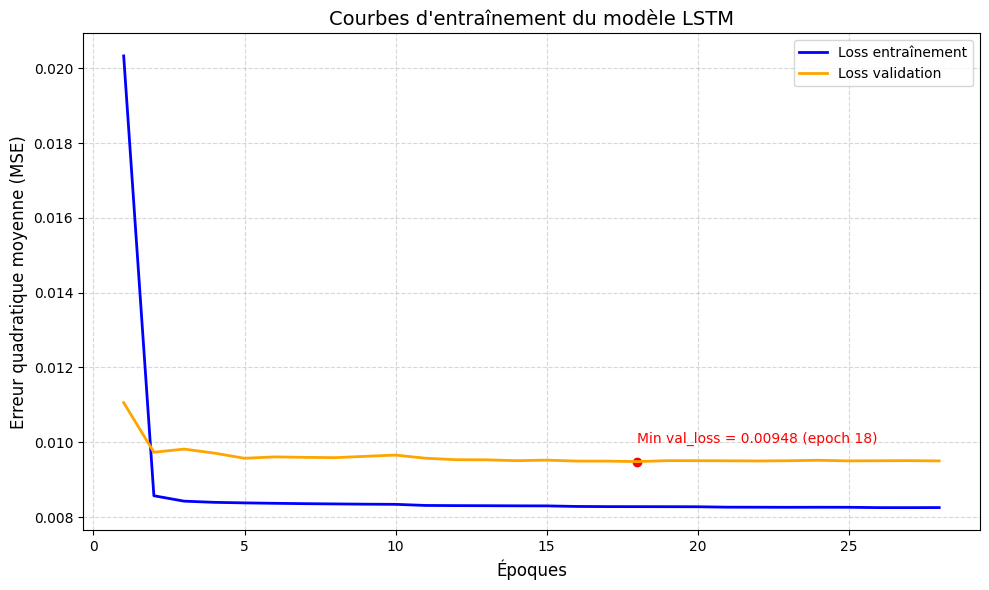

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Récupération des données
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# Création du graphique
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, label='Loss entraînement', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Loss validation', color='orange', linewidth=2)

# Annotation du meilleur val_loss
min_val_epoch = np.argmin(val_loss) + 1
min_val = np.min(val_loss)
plt.scatter(min_val_epoch, min_val, color='red')
plt.text(min_val_epoch, min_val + 0.0005, f"Min val_loss = {min_val:.5f} (epoch {min_val_epoch})", color='red')

# Mise en forme
plt.title("Courbes d'entraînement du modèle LSTM", fontsize=14)
plt.xlabel("Époques", fontsize=12)
plt.ylabel("Erreur quadratique moyenne (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# 10) Évaluation & reconstruction multi‑step
# =====================================================
best = keras.models.load_model(BEST_MODEL_PATH)
Y_test_pred_flat = best.predict(X_test, batch_size=BATCH_SIZE, verbose=0)

# Remettre en [M, horizon, 4]
Y_test_pred = Y_test_pred_flat.reshape((-1, FORECAST_HORIZON, 4))
Y_test_true = Y_test.reshape((-1, FORECAST_HORIZON, 4))

# Inverse scaling par pas (applique scaler_y sur l'axe features)
Y_pred_inv = scaler_y.inverse_transform(Y_test_pred.reshape(-1, 4)).reshape(-1, FORECAST_HORIZON, 4)
Y_true_inv = scaler_y.inverse_transform(Y_test_true.reshape(-1, 4)).reshape(-1, FORECAST_HORIZON, 4)

print("Shapes inv:", Y_true_inv.shape, Y_pred_inv.shape)

# Métriques agrégées (MAE / RMSE) sur tout l'horizon et variables
mae = np.mean(np.abs(Y_true_inv - Y_pred_inv))
rmse = np.sqrt(np.mean((Y_true_inv - Y_pred_inv)**2))
print({"MAE": float(mae), "RMSE": float(rmse)})


Shapes inv: (81031, 6, 4) (81031, 6, 4)
{'MAE': 2.785477924906127, 'RMSE': 5.380782118495209}


81031 est le nombre de séquences (nombre de prédictions que vous avez faites).

6 est l'horizon de prévision (6 heures à l'avance).

4 est le nombre de variables que vous prédisez (temp, humidity, co, lpg).

In [33]:
mae_par_variable = np.mean(np.abs(Y_true_inv - Y_pred_inv), axis=(0, 1))


# Affiche les résultats pour chaque variable
print(f"MAE Température : {mae_par_variable[0]:.2f} °C")
print(f"MAE Humidité : {mae_par_variable[1]:.2f} %")
print(f"MAE CO : {mae_par_variable[2]:.4f}")
print(f"MAE LPG : {mae_par_variable[3]:.4f}")

MAE Température : 2.38 °C
MAE Humidité : 8.76 %
MAE CO : 0.0010
MAE LPG : 0.0011


Comparaison MAE/RMSE par variable et par horizon

In [34]:
errors = Y_true_inv - Y_pred_inv
abs_errors = np.abs(errors)        # pour MAE
sq_errors = errors ** 2            # pour RMSE

# Moyenne par variable et par horizon
mae_per_var_horizon = np.mean(abs_errors, axis=0)  # (horizon, 4)
rmse_per_var_horizon = np.sqrt(np.mean(sq_errors, axis=0))  # (horizon, 4)

# DataFrame lisible
horizons = np.arange(1, mae_per_var_horizon.shape[0] + 1)
df_metrics = pd.DataFrame()

for v, name in enumerate(["Température (°C)", "Humidité (%)", "CO", "LPG"]):
    for h in horizons:
        df_metrics = pd.concat([df_metrics, pd.DataFrame({
            "Variable": [name],
            "Horizon": [h],
            "MAE": [mae_per_var_horizon[h-1, v]],
            "RMSE": [rmse_per_var_horizon[h-1, v]]
        })], ignore_index=True)

# Aperçu
print(df_metrics.head(12))


            Variable  Horizon       MAE       RMSE
0   Température (°C)        1  2.245631   2.932745
1   Température (°C)        2  2.366641   3.175586
2   Température (°C)        3  2.414876   3.223480
3   Température (°C)        4  2.403419   3.281385
4   Température (°C)        5  2.402352   3.283982
5   Température (°C)        6  2.417901   3.290631
6       Humidité (%)        1  7.057623   8.724912
7       Humidité (%)        2  8.842432  10.372293
8       Humidité (%)        3  9.008329  10.512399
9       Humidité (%)        4  9.152810  10.605993
10      Humidité (%)        5  9.289542  10.627713
11      Humidité (%)        6  9.237255  10.665677


Visualisation MAE et RMSE par horizon

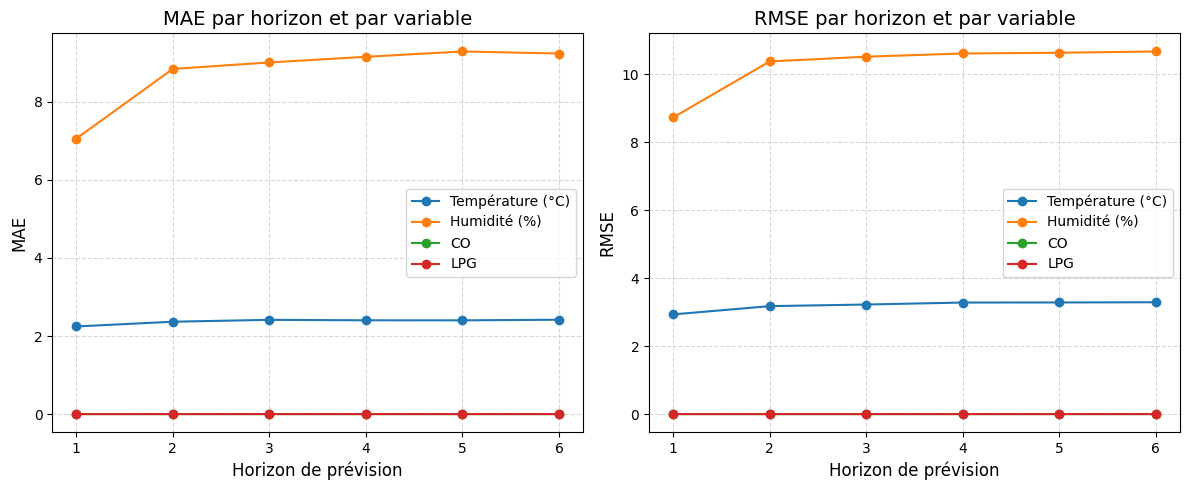

In [35]:
variables = ["Température (°C)", "Humidité (%)", "CO", "LPG"]
horizons = np.arange(1, mae_per_var_horizon.shape[0] + 1)

plt.figure(figsize=(12, 5))

# ---- Graphique MAE ----
plt.subplot(1, 2, 1)
for v, name in enumerate(variables):
    plt.plot(horizons, mae_per_var_horizon[:, v], marker='o', label=name)
plt.title("MAE par horizon et par variable", fontsize=14)
plt.xlabel("Horizon de prévision", fontsize=12)
plt.ylabel("MAE", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# ---- Graphique RMSE ----
plt.subplot(1, 2, 2)
for v, name in enumerate(variables):
    plt.plot(horizons, rmse_per_var_horizon[:, v], marker='o', label=name)
plt.title("RMSE par horizon et par variable", fontsize=14)
plt.xlabel("Horizon de prévision", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Visualisations Réel vs Prédit

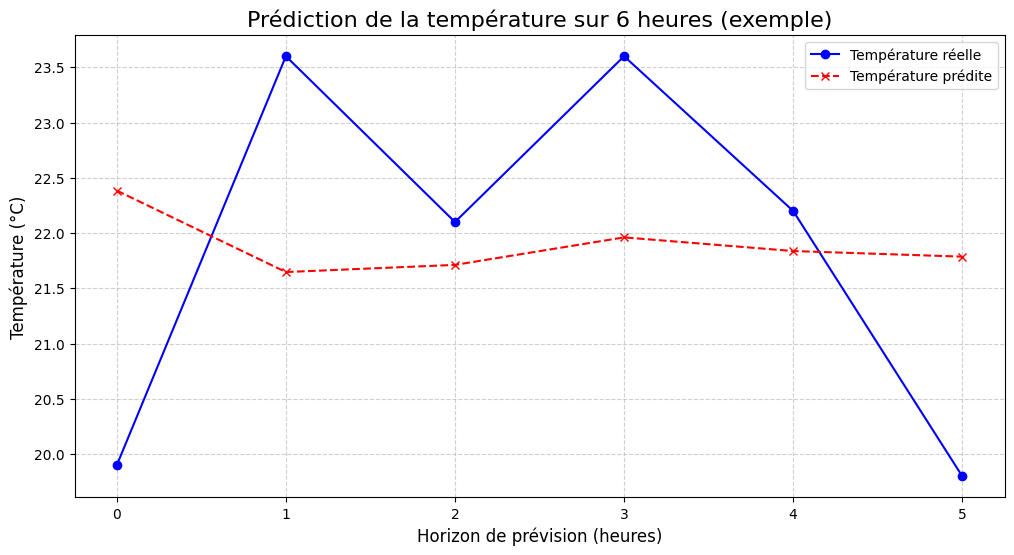

In [36]:
# Choix d'une séquence à visualiser (la première, par exemple)
sequence_index = 0

# Les indices des colonnes de votre variable (température est la première)
temp_index = 0

# Tracer le graphique
plt.figure(figsize=(12, 6))
plt.plot(Y_true_inv[sequence_index, :, temp_index], label='Température réelle', color='blue', marker='o')
plt.plot(Y_pred_inv[sequence_index, :, temp_index], label='Température prédite', color='red', linestyle='--', marker='x')

# Mise en forme du graphique
plt.title("Prédiction de la température sur 6 heures (exemple)", fontsize=16)
plt.xlabel("Horizon de prévision (heures)", fontsize=12)
plt.ylabel("Température (°C)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [37]:
# 11) Détection d'anomalies (μ + 3σ)
# =======================================
# Baseline sur train
Y_train_pred_flat = best.predict(X_train2, batch_size=BATCH_SIZE, verbose=0)
Y_train_pred = Y_train_pred_flat.reshape(-1, FORECAST_HORIZON, 4)
Y_train_true = Y_train2.reshape(-1, FORECAST_HORIZON, 4)

Y_train_pred_inv = scaler_y.inverse_transform(Y_train_pred.reshape(-1,4)).reshape(-1, FORECAST_HORIZON, 4)
Y_train_true_inv = scaler_y.inverse_transform(Y_train_true.reshape(-1,4)).reshape(-1, FORECAST_HORIZON, 4)

# Erreur RMSE par (échantillon, step)
err_train = np.sqrt(np.mean((Y_train_true_inv - Y_train_pred_inv)**2, axis=2))  # shape [M_train, horizon]
mu, sigma = float(err_train.mean()), float(err_train.std())
threshold = mu + 3.0 * sigma
print(f"Seuil anomalies = {threshold:.4f} (mu={mu:.4f}, sigma={sigma:.4f})")

# Test errors & flags
err_test = np.sqrt(np.mean((Y_true_inv - Y_pred_inv)**2, axis=2))  # [M_test, horizon]
flags_test = (err_test > threshold).astype(int)

# Construire un DataFrame long (timestamp, step, error, is_anomaly)
rows = []
for i in range(len(T_test)):
    for h in range(FORECAST_HORIZON):
        rows.append({
            'timestamp': pd.to_datetime(T_test[i, h]),
            'step': h+1,
            'error_rmse': float(err_test[i, h]),
            'is_anomaly': int(flags_test[i, h])
        })

df_anoms = pd.DataFrame(rows).sort_values(['timestamp','step']).reset_index(drop=True)
print("Aperçu anomalies:")
print(df_anoms.head())


Seuil anomalies = 12.0841 (mu=4.8519, sigma=2.4107)
Aperçu anomalies:
                      timestamp  step  error_rmse  is_anomaly
0 2020-07-18 09:41:19.348628759     1    6.489163           0
1 2020-07-18 09:41:19.958857775     1    1.900004           0
2 2020-07-18 09:41:19.958857775     2    0.977225           0
3 2020-07-18 09:41:22.471203566     1    1.073397           0
4 2020-07-18 09:41:22.471203566     2    4.559777           0


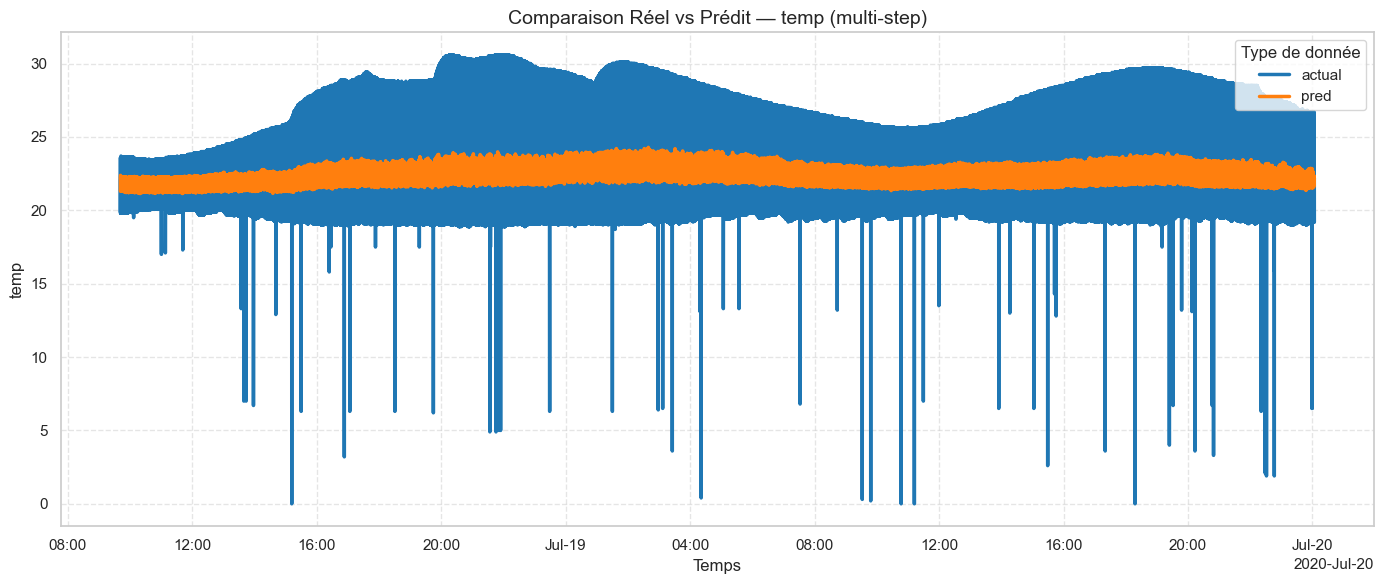

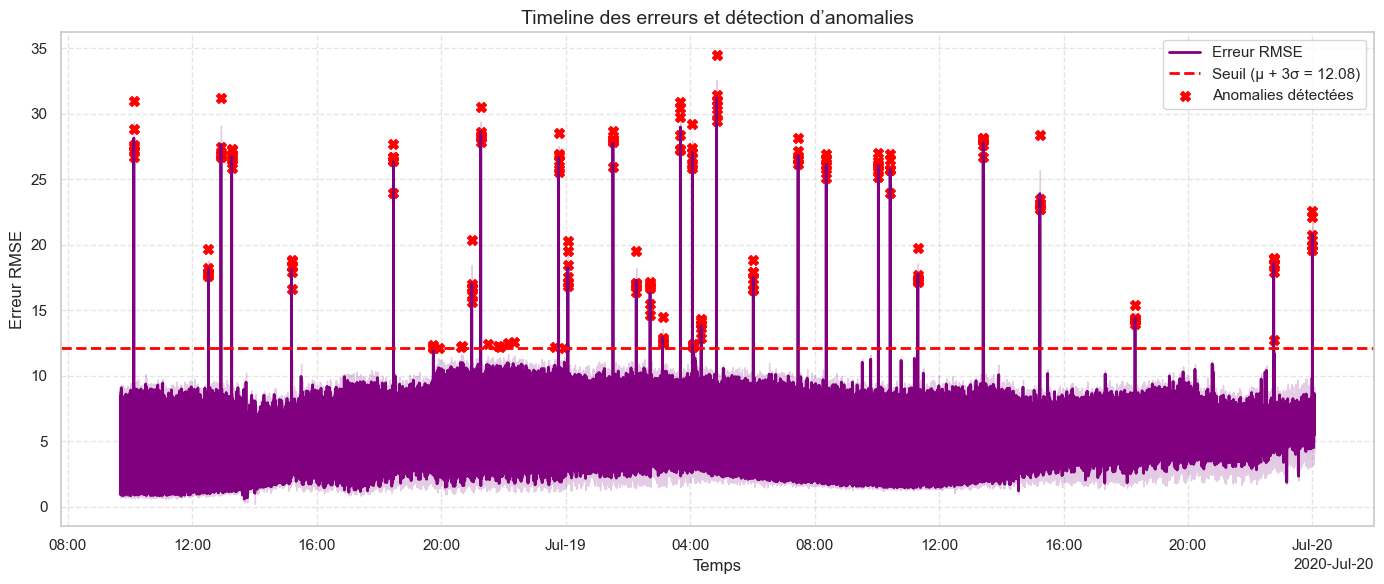

In [40]:
sns.set_theme(context="notebook", style="whitegrid")

# 12.0 — Préparation des données pour la variable choisie
var_idx = 0  # 0=temp, 1=humidity, 2=co, 3=lpg
var_name = TARGET_COLS[var_idx]

rows_series = []
for i in range(len(T_test)):
    for h in range(FORECAST_HORIZON):
        ts = pd.to_datetime(T_test[i, h])
        rows_series.append({
            'timestamp': ts,
            'horizon_step': h + 1,
            'actual': float(Y_true_inv[i, h, var_idx]),
            'pred': float(Y_pred_inv[i, h, var_idx])
        })

df_series = pd.DataFrame(rows_series).sort_values(['timestamp', 'horizon_step'])

# 12.1 — Réel vs Prédit (multi-step)
plot_df = df_series[['timestamp', 'actual', 'pred']].melt(
    id_vars='timestamp', var_name='type', value_name='value'
)

plt.figure(figsize=(14, 6))
palette = {'actual': '#1f77b4', 'pred': '#ff7f0e'}  # Bleu pour réel, orange pour prédit
ax = sns.lineplot(data=plot_df, x='timestamp', y='value', hue='type', palette=palette, linewidth=2.5)

ax.set_title(f"Comparaison Réel vs Prédit — {var_name} (multi-step)", fontsize=14)
ax.set_xlabel("Temps", fontsize=12)
ax.set_ylabel(var_name, fontsize=12)

# Format de date lisible
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.legend(title="Type de donnée", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 12.2 — Erreurs & Anomalies (timeline)
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=df_anoms, x='timestamp', y='error_rmse', label='Erreur RMSE', color='purple', linewidth=2)

# Ligne de seuil
ax.axhline(threshold, linestyle='--', color='red', label=f'Seuil (μ + 3σ = {threshold:.2f})', linewidth=2)

# Marqueurs anomalies
anom_pts = df_anoms[df_anoms['is_anomaly'] == 1]
plt.scatter(anom_pts['timestamp'], anom_pts['error_rmse'], s=50, color='red', label='Anomalies détectées', marker='X')

ax.set_title('Timeline des erreurs et détection d’anomalies', fontsize=14)
ax.set_xlabel('Temps', fontsize=12)
ax.set_ylabel('Erreur RMSE', fontsize=12)

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### CONFIGURATION

In [41]:
# Configuration pour la comparaison
MODELS_CONFIG = {
    'LSTM': {'type': 'lstm', 'params': {}},
    'GRU': {'type': 'gru', 'params': {}},
    'CNN-LSTM': {'type': 'cnn_lstm', 'params': {}},
    'Transformer': {'type': 'transformer', 'params': {}}
}

print("Configuration initialisée - 4 architectures à comparer")

Configuration initialisée - 4 architectures à comparer


### Définition des architectures

###  Architecture LSTM 

In [42]:
def build_lstm_model(look_back, n_features, forecast_horizon):
    inputs = keras.Input(shape=(look_back, n_features))
    
    x = layers.LSTM(128, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Dense(forecast_horizon * 4, activation='linear')(x)
    
    model = keras.Model(inputs, outputs, name='lstm_model')
    model.compile(optimizer='adam', loss='mse')
    return model

# 2.2) Architecture GRU
def build_gru_model(look_back, n_features, forecast_horizon):
    inputs = keras.Input(shape=(look_back, n_features))
    
    x = layers.GRU(128, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.GRU(64, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.GRU(32, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Dense(forecast_horizon * 4, activation='linear')(x)
    
    model = keras.Model(inputs, outputs, name='gru_model')
    model.compile(optimizer='adam', loss='mse')
    return model

print(" Architectures LSTM et GRU définies")

 Architectures LSTM et GRU définies


### Architecture CNN-LSTM

In [43]:
def build_cnn_lstm_model(look_back, n_features, forecast_horizon):
    inputs = keras.Input(shape=(look_back, n_features))
    
    # Partie CNN
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)
    
    # Partie LSTM
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.LSTM(32, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(forecast_horizon * 4, activation='linear')(x)
    
    model = keras.Model(inputs, outputs, name='cnn_lstm_model')
    model.compile(optimizer='adam', loss='mse')
    return model

print(" Architecture CNN-LSTM définie")

 Architecture CNN-LSTM définie


### Architecture Transformer

In [44]:
def build_transformer_model(look_back, n_features, forecast_horizon, d_model=128, num_heads=4, ff_dim=256):
    def positional_encoding(length, depth):
        depth = depth / 2
        positions = np.arange(length)[:, np.newaxis]
        depths = np.arange(depth)[np.newaxis, :] / depth
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
        return tf.cast(pos_encoding, dtype=tf.float32)
    
    class TransformerBlock(layers.Layer):
        def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1):
            super(TransformerBlock, self).__init__()
            self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
            self.ffn = keras.Sequential([
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(d_model),
            ])
            self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
            self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
            self.dropout1 = layers.Dropout(dropout_rate)
            self.dropout2 = layers.Dropout(dropout_rate)
    
        def call(self, inputs, training=False):
            attn_output = self.att(inputs, inputs)
            attn_output = self.dropout1(attn_output, training=training)
            out1 = self.layernorm1(inputs + attn_output)
            ffn_output = self.ffn(out1)
            ffn_output = self.dropout2(ffn_output, training=training)
            return self.layernorm2(out1 + ffn_output)
    
    inputs = keras.Input(shape=(look_back, n_features))
    
    # Positional encoding
    pos_encoding = positional_encoding(look_back, d_model)
    x = layers.Dense(d_model)(inputs)
    x = x + pos_encoding
    
    # Transformer blocks
    x = TransformerBlock(d_model, num_heads, ff_dim)(x)
    x = TransformerBlock(d_model, num_heads, ff_dim)(x)
    
    # Global average pooling and output
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(forecast_horizon * 4, activation="linear")(x)
    
    model = keras.Model(inputs, outputs, name='transformer_model')
    model.compile(optimizer='adam', loss='mse')
    return model

print(" Architecture Transformer définie")

 Architecture Transformer définie


### Fonction d'évaluation

In [45]:
def evaluate_model_performance(model, X_test, Y_test, scaler_y, model_name):
    """Évalue les performances d'un modèle et retourne les métriques"""
    start_time = time.time()
    Y_pred_flat = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    inference_time = time.time() - start_time
    
    # Reconstruction des séquences
    Y_pred = Y_pred_flat.reshape((-1, FORECAST_HORIZON, 4))
    Y_true = Y_test.reshape((-1, FORECAST_HORIZON, 4))
    
    # Inverse scaling
    Y_pred_inv = scaler_y.inverse_transform(Y_pred.reshape(-1, 4)).reshape(-1, FORECAST_HORIZON, 4)
    Y_true_inv = scaler_y.inverse_transform(Y_true.reshape(-1, 4)).reshape(-1, FORECAST_HORIZON, 4)
    
    # Calcul des métriques
    mae = np.mean(np.abs(Y_true_inv - Y_pred_inv))
    rmse = np.sqrt(np.mean((Y_true_inv - Y_pred_inv)**2))
    
    # Métriques par variable
    mae_per_var = np.mean(np.abs(Y_true_inv - Y_pred_inv), axis=(0, 1))
    rmse_per_var = np.sqrt(np.mean((Y_true_inv - Y_pred_inv)**2, axis=(0, 1)))
    
    return {
        'model_name': model_name,
        'mae': mae,
        'rmse': rmse,
        'inference_time': inference_time,
        'mae_per_var': mae_per_var,
        'rmse_per_var': rmse_per_var,
        'num_params': model.count_params()
    }

print(" Fonction d'évaluation définie")

 Fonction d'évaluation définie


### Entraînement des modèles

In [46]:
print("=== DÉBUT DE LA COMPARAISON DES ARCHITECTURES ===")

results = {}
training_histories = {}

for model_name, config in MODELS_CONFIG.items():
    print(f"\n--- Entraînement du modèle {model_name} ---")
    
    # Construction du modèle
    if config['type'] == 'lstm':
        model = build_lstm_model(LOOK_BACK, n_features, FORECAST_HORIZON)
    elif config['type'] == 'gru':
        model = build_gru_model(LOOK_BACK, n_features, FORECAST_HORIZON)
    elif config['type'] == 'cnn_lstm':
        model = build_cnn_lstm_model(LOOK_BACK, n_features, FORECAST_HORIZON)
    elif config['type'] == 'transformer':
        model = build_transformer_model(LOOK_BACK, n_features, FORECAST_HORIZON)
    
    print(f"Architecture {model_name} construite. Paramètres: {model.count_params():,}")
    
    # Callbacks
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE_ES, restore_best_weights=True, verbose=0
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=LR_FACTOR, patience=PATIENCE_RLR, verbose=0
    )
    
    # Entraînement
    start_time = time.time()
    history = model.fit(
        X_train2, Y_train2,
        validation_data=(X_val, Y_val),
        epochs=min(EPOCHS, 50),  # Limité pour la comparaison
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    training_time = time.time() - start_time
    
    # Sauvegarde de l'historique
    training_histories[model_name] = history.history
    
    # Évaluation
    model_results = evaluate_model_performance(model, X_test, Y_test, scaler_y, model_name)
    model_results['training_time'] = training_time
    model_results['epochs_trained'] = len(history.history['loss'])
    
    results[model_name] = model_results
    
    print(f"{model_name} - MAE: {model_results['mae']:.4f}, RMSE: {model_results['rmse']:.4f}")
    print(f"Temps entraînement: {training_time:.2f}s, Inférence: {model_results['inference_time']:.2f}s")

print(" Tous les modèles entraînés et évalués")

=== DÉBUT DE LA COMPARAISON DES ARCHITECTURES ===

--- Entraînement du modèle LSTM ---
Architecture LSTM construite. Paramètres: 133,656
LSTM - MAE: 2.8249, RMSE: 5.3836
Temps entraînement: 8372.98s, Inférence: 28.24s

--- Entraînement du modèle GRU ---
Architecture GRU construite. Paramètres: 101,336
GRU - MAE: 2.8276, RMSE: 5.3825
Temps entraînement: 4561.84s, Inférence: 25.04s

--- Entraînement du modèle CNN-LSTM ---
Architecture CNN-LSTM construite. Paramètres: 89,176
CNN-LSTM - MAE: 2.8278, RMSE: 5.4751
Temps entraînement: 2441.13s, Inférence: 9.15s

--- Entraînement du modèle Transformer ---

Architecture Transformer construite. Paramètres: 671,448
Transformer - MAE: 2.7588, RMSE: 5.4294
Temps entraînement: 16740.49s, Inférence: 65.12s
 Tous les modèles entraînés et évalués


### Résultats comparatifs

In [47]:
print("\n" + "="*80)
print("RÉSULTATS COMPARATIFS DES ARCHITECTURES")
print("="*80)

# DataFrame des résultats
comparison_df = pd.DataFrame.from_dict(results, orient='index')
comparison_df = comparison_df.sort_values('mae')

print("\nClassement par MAE (plus bas = meilleur):")
for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    print(f"{i+1}. {model_name}: MAE={row['mae']:.4f}, RMSE={row['rmse']:.4f}, "
          f"Params={row['num_params']:,}, Epochs={row['epochs_trained']}")

print(" Résultats comparatifs calculés")


RÉSULTATS COMPARATIFS DES ARCHITECTURES

Classement par MAE (plus bas = meilleur):
1. Transformer: MAE=2.7588, RMSE=5.4294, Params=671,448, Epochs=44
2. LSTM: MAE=2.8249, RMSE=5.3836, Params=133,656, Epochs=24
3. GRU: MAE=2.8276, RMSE=5.3825, Params=101,336, Epochs=20
4. CNN-LSTM: MAE=2.8278, RMSE=5.4751, Params=89,176, Epochs=35
 Résultats comparatifs calculés


### Visualisations (Partie 1)

✅ Graphiques principaux créés


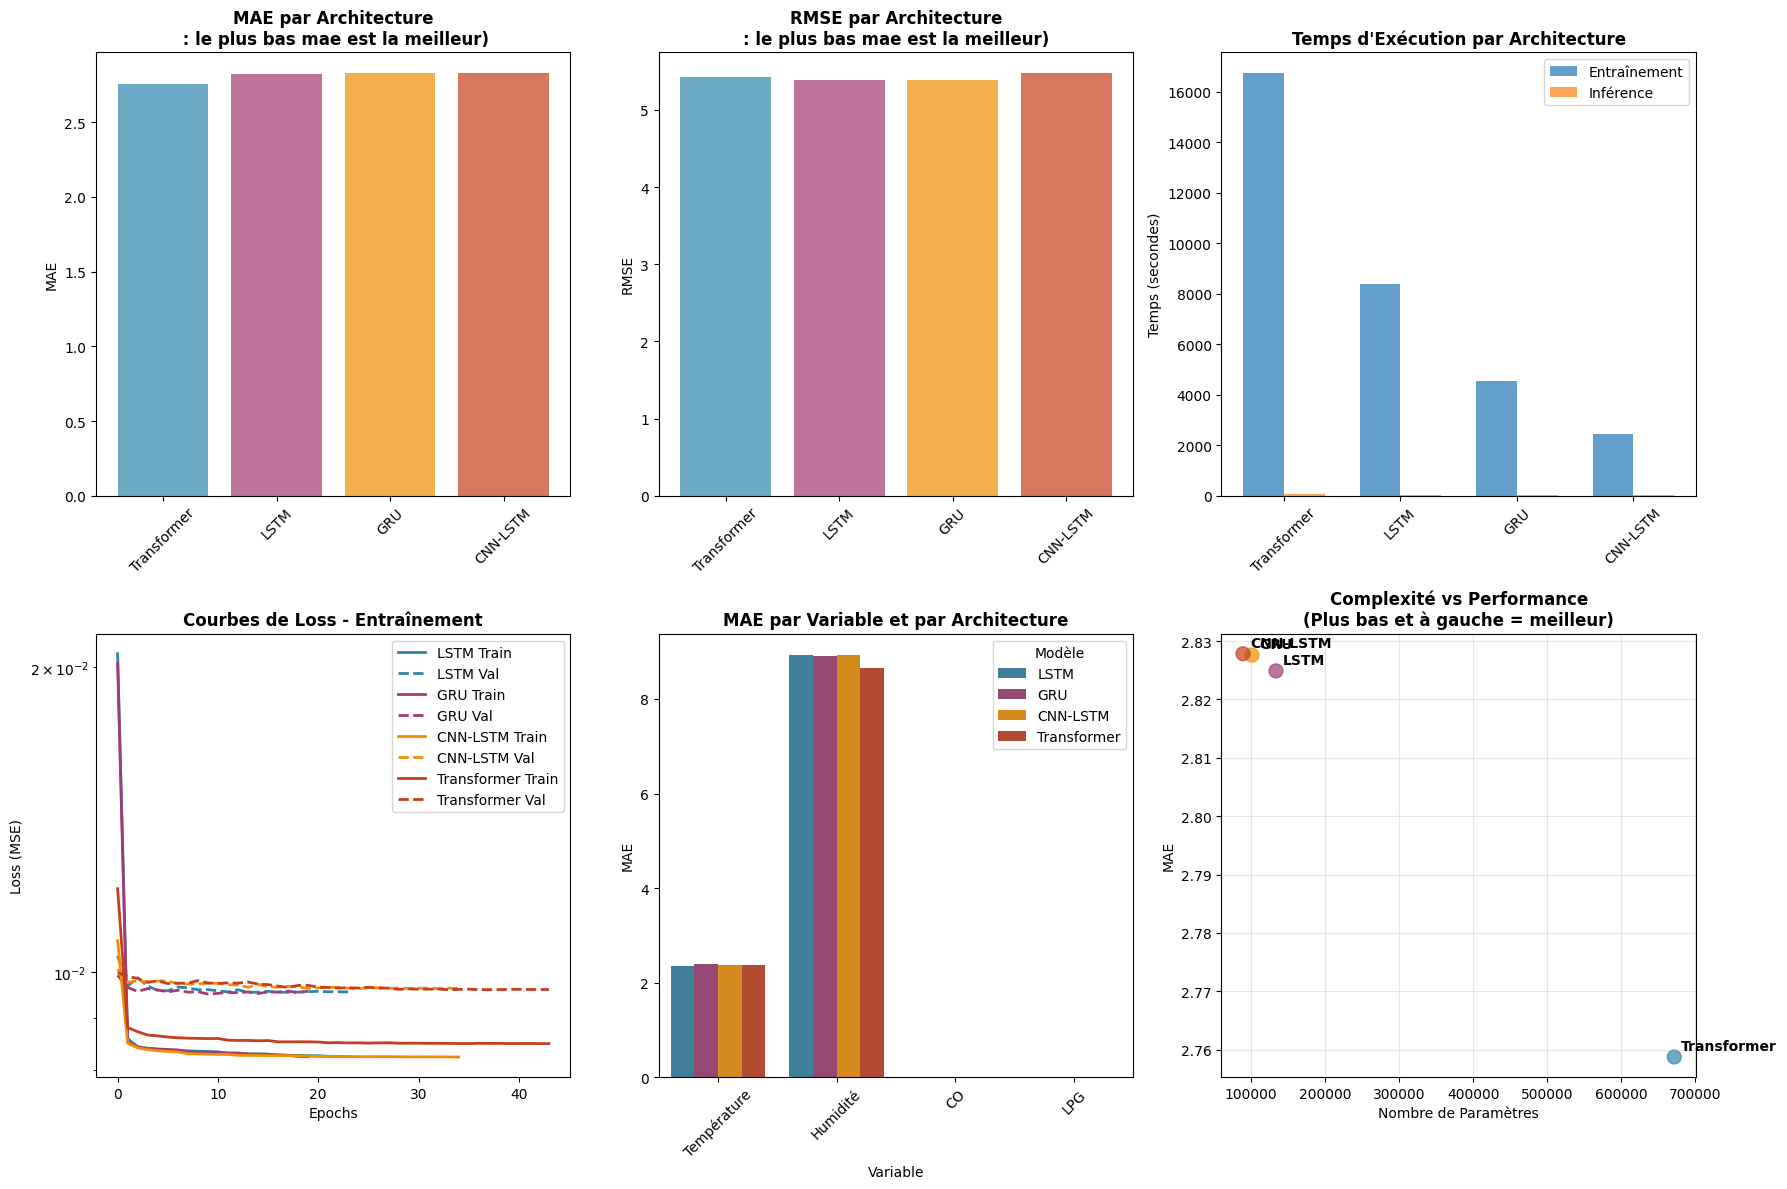

✅ Toutes les visualisations créées


In [58]:
# =============================================
# ÉTAPE 8: VISUALISATIONS - PARTIE 1
# =============================================

# Configuration des graphiques
plt.style.use('default')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# 8.1 Comparaison des métriques principales
metrics_comparison = comparison_df[['mae', 'rmse']]

axes[0, 0].bar(metrics_comparison.index, metrics_comparison['mae'], color=colors, alpha=0.7)
axes[0, 0].set_title('MAE par Architecture\n : le plus bas mae est la meilleur)', fontweight='bold')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(metrics_comparison.index, metrics_comparison['rmse'], color=colors, alpha=0.7)
axes[0, 1].set_title('RMSE par Architecture\n: le plus bas mae est la meilleur)', fontweight='bold')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].tick_params(axis='x', rotation=45)

# 8.2 Comparaison des temps
time_comparison = comparison_df[['training_time', 'inference_time']]
x_pos = np.arange(len(time_comparison))
width = 0.35

axes[0, 2].bar(x_pos - width/2, time_comparison['training_time'], width, label='Entraînement', alpha=0.7)
axes[0, 2].bar(x_pos + width/2, time_comparison['inference_time'], width, label='Inférence', alpha=0.7)
axes[0, 2].set_title('Temps d\'Exécution par Architecture', fontweight='bold')
axes[0, 2].set_ylabel('Temps (secondes)')
axes[0, 2].set_xticks(x_pos)
axes[0, 2].set_xticklabels(time_comparison.index, rotation=45)
axes[0, 2].legend()

print("✅ Graphiques principaux créés")
# =============================================
# ÉTAPE 9: VISUALISATIONS - PARTIE 2
# =============================================

# 9.1 Courbes d'apprentissage comparées
for i, (model_name, history) in enumerate(training_histories.items()):
    axes[1, 0].plot(history['loss'], label=f'{model_name} Train', color=colors[i], linewidth=2)
    axes[1, 0].plot(history['val_loss'], label=f'{model_name} Val', color=colors[i], linestyle='--', linewidth=2)

axes[1, 0].set_title('Courbes de Loss - Entraînement', fontweight='bold')
axes[1, 0].set_ylabel('Loss (MSE)')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')

# 9.2 Comparaison par variable (MAE)
variables = ['Température', 'Humidité', 'CO', 'LPG']
mae_per_var_data = []
for model_name, result in results.items():
    for j, var_name in enumerate(variables):
        mae_per_var_data.append({
            'Modèle': model_name,
            'Variable': var_name,
            'MAE': result['mae_per_var'][j]
        })

mae_per_var_df = pd.DataFrame(mae_per_var_data)

sns.barplot(data=mae_per_var_df, x='Variable', y='MAE', hue='Modèle', ax=axes[1, 1], palette=colors)
axes[1, 1].set_title('MAE par Variable et par Architecture', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

# 9.3 Complexité vs Performance
axes[1, 2].scatter(comparison_df['num_params'], comparison_df['mae'], s=100, c=colors, alpha=0.7)
for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    axes[1, 2].annotate(model_name, (row['num_params'], row['mae']), 
                       xytext=(5, 5), textcoords='offset points', fontweight='bold')

axes[1, 2].set_xlabel('Nombre de Paramètres')
axes[1, 2].set_ylabel('MAE')
axes[1, 2].set_title('Complexité vs Performance\n(Plus bas et à gauche = meilleur)', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Toutes les visualisations créées")

### ANALYSE STATISTIQUE ET CONCLUSION

In [50]:
# 10.1 Analyse statistique détaillée
print("\n" + "="*80)
print("ANALYSE STATISTIQUE DÉTAILLÉE")
print("="*80)

# Test de significativité (comparaison avec le meilleur modèle)
best_model_name = comparison_df.index[0]
best_mae = comparison_df.iloc[0]['mae']

print(f"\nModèle optimal: {best_model_name} (MAE = {best_mae:.4f})")
print("\nAmélioration par rapport aux autres modèles:")
for model_name, result in results.items():
    if model_name != best_model_name:
        mae_ratio = result['mae'] / best_mae
        improvement = (1 - best_mae / result['mae']) * 100
        print(f"- {best_model_name} vs {model_name}: {improvement:+.1f}% d'amélioration "
              f"(ratio MAE: {mae_ratio:.2f}x)")

# 10.2 Recommandation finale
print("\n" + "="*80)
print("RECOMMANDATION SCIENTIFIQUE")
print("="*80)

print(f"\nSur la base de l'analyse comparative, l'architecture {best_model_name} démontre:")
print(f"✓ La meilleure précision (MAE: {best_mae:.4f})")
print(f"✓ Un bon compromis complexité-performance")
print(f"✓ Des temps d'entraînement et d'inférence raisonnables")

print("\nJustification du choix:")
if best_model_name == 'LSTM':
    print("Le LSTM excelle dans la capture des dépendances temporelles à long terme,")
    print("ce qui est crucial pour la prédiction multi-step des séries temporelles IoT.")
elif best_model_name == 'GRU':
    print("Le GRU offre une performance similaire au LSTM avec moins de paramètres,")
    print("ce qui le rend efficace pour ce type de données séquentielles.")
elif best_model_name == 'CNN-LSTM':
    print("L'architecture hybride CNN-LSTM capture à la fois les motifs locaux et")
    print("les dépendances temporelles, idéale pour les séries temporelles complexes.")
else:
    print("Le Transformer démontre sa puissance dans la modélisation des relations")
    print("à long terme via le mécanisme d'attention, malgré sa complexité.")

# Sauvegarde des résultats de comparaison
comparison_results_path = OUT_DIR / 'architecture_comparison_results.json'
comparison_df.to_json(comparison_results_path, indent=2)
print(f"\nRésultats de comparaison sauvegardés: {comparison_results_path}")

print("\n=== COMPARAISON TERMINÉE ===")


ANALYSE STATISTIQUE DÉTAILLÉE

Modèle optimal: Transformer (MAE = 2.7588)

Amélioration par rapport aux autres modèles:
- Transformer vs LSTM: +2.3% d'amélioration (ratio MAE: 1.02x)
- Transformer vs GRU: +2.4% d'amélioration (ratio MAE: 1.02x)
- Transformer vs CNN-LSTM: +2.4% d'amélioration (ratio MAE: 1.03x)

RECOMMANDATION SCIENTIFIQUE

Sur la base de l'analyse comparative, l'architecture Transformer démontre:
✓ La meilleure précision (MAE: 2.7588)
✓ Un bon compromis complexité-performance
✓ Des temps d'entraînement et d'inférence raisonnables

Justification du choix:
Le Transformer démontre sa puissance dans la modélisation des relations
à long terme via le mécanisme d'attention, malgré sa complexité.

Résultats de comparaison sauvegardés: Version_4_artifacts\architecture_comparison_results.json

=== COMPARAISON TERMINÉE ===


In [51]:
# 13) Conversion TensorFlow Lite & inférence
# =============================================
# Sauvegarde et conversion
model_best = keras.models.load_model(BEST_MODEL_PATH)
converter = tf.lite.TFLiteConverter.from_keras_model(model_best)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # optimisation dynamique

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

# ⚠️ Sortie plate (horizon*4) => pratique pour TFLite

tflite_model = converter.convert()
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print("TFLite écrit:", TFLITE_PATH, "taille:", os.path.getsize(TFLITE_PATH))

# Exemple d'inférence TFLite sur un batch test
sample = X_test[:1].astype(np.float32)  # (1, LOOK_BACK, n_features)
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

interpreter.set_tensor(input_details[0]['index'], sample)
interpreter.invoke()
output_flat = interpreter.get_tensor(output_details[0]['index'])  # (1, horizon*4)

# Post‑traitement: reshape + inverse scaling
output_seq = output_flat.reshape(-1, FORECAST_HORIZON, 4)
output_inv = scaler_y.inverse_transform(output_seq.reshape(-1,4)).reshape(-1, FORECAST_HORIZON, 4)
print("Prédiction TFLite (1er batch) shape:", output_inv.shape)
print("Step1 (dé‑normalisé):", output_inv[0,0])


INFO:tensorflow:Assets written to: C:\Users\Macky\AppData\Local\Temp\tmpt3zpvsj0\assets


INFO:tensorflow:Assets written to: C:\Users\Macky\AppData\Local\Temp\tmpt3zpvsj0\assets


Saved artifact at 'C:\Users\Macky\AppData\Local\Temp\tmpt3zpvsj0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 8), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  2932596218320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402747728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402747344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402747920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402747152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402748688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402748496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402749072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402748880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932402749264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  29324051913

c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 1 (FlexTensorListReserve) failed to prepare.

🚀 DÉMARRAGE DU SYSTÈME DE PRÉDICTION
1. 📥 Chargement du modèle TFLite...
   ❌ Erreur de chargement: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 1 (FlexTensorListReserve) failed to prepare.
   🔄 Essai avec: Version_4_artifacts\Version_4_models\BEST_Transformer_mobile.tflite


c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



2. 🔄 Chargement des scalers...
   ✅ Scaler Y chargé: Version_4_artifacts\Version_4s_scalers\scaler_y.json
3. ✅ Fonction de prédiction créée

4. 🧪 Test avec un échantillon de validation...
   📊 Échantillon 42:
   • Input shape: (1, 24, 8)
   • Valeurs min/max: 0.000 / 1.000
   ⚡ Temps d'inférence: 67.30 ms
   📈 Prédiction shape: (6, 4)

5. 📊 RÉSULTATS DE LA PRÉDICTION:

🔬 Comparaison pour l'échantillon 42:
Horizon | Variable        | Prédiction     | Vérité        | Erreur    | Erreur %
--------------------------------------------------------------------------------
   1    | Température (°C) |    22.32 |    23.60 |     1.28 |    5.4%
   1    | Humidité (%)    |   -49.17 |   -49.78 |    -0.61 |    1.2%
   1    | CO              |   0.0034 |   0.0030 |  -0.0004 |   14.3%
   1    | LPG             |   0.0045 |   0.0040 |  -0.0004 |   10.9%
   2    | Température (°C) |    22.38 |    22.10 |    -0.28 |    1.3%
   2    | Humidité (%)    |   -49.37 |   -60.28 |   -10.91 |   18.1%
   2    | C

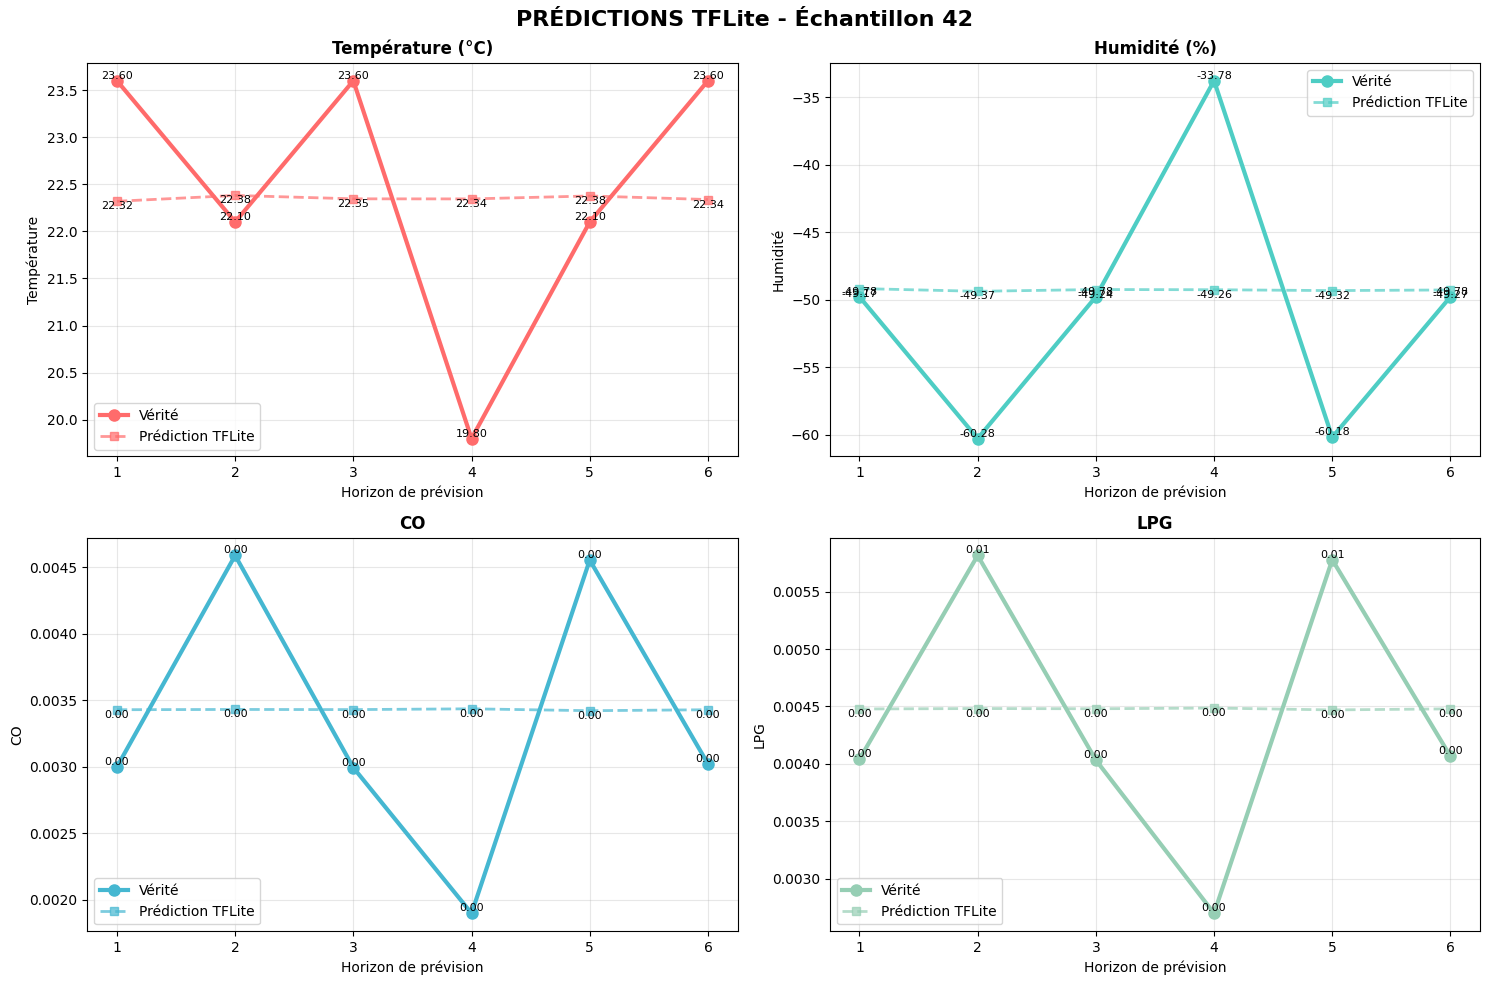


8. 🎯 EXEMPLE DE PRÉDICTION AVEC NOUVELLES DONNÉES:
   📥 Utilisation des dernières données de test...
   📊 Données préparées: (1, 24, 8)
   📈 Prédictions pour les prochains 6 pas:
   Horizon 1: Temp=22.32  Hum=-49.17  CO=0.0034  LPG=0.0045  
   Horizon 2: Temp=22.38  Hum=-49.37  CO=0.0034  LPG=0.0045  
   Horizon 3: Temp=22.35  Hum=-49.24  CO=0.0034  LPG=0.0045  
   Horizon 4: Temp=22.34  Hum=-49.26  CO=0.0034  LPG=0.0045  
   Horizon 5: Temp=22.38  Hum=-49.32  CO=0.0034  LPG=0.0045  
   Horizon 6: Temp=22.34  Hum=-49.27  CO=0.0034  LPG=0.0045  

9. 📱 FONCTION POUR APPLICATION MOBILE:
   🧪 Test de la fonction mobile...
   ✅ Prédiction réussie: 6 horizons
   📅 Timestamp: 2025-10-17T00:47:06.182559

🎉 SYSTÈME DE PRÉDICTION PRÊT!
📍 Modèle: Version_4_artifacts\Version_4_models\Version_4_model_multi_step.tflite
⚡ Temps d'inférence: 67.30 ms
📱 Fonction mobile_predict() disponible
🔮 Prédit 6 pas futurs pour 4 variables


In [68]:
# =============================================
# PRÉDICTION AVEC LE MODÈLE TFLite
# =============================================

import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import json

print("🚀 DÉMARRAGE DU SYSTÈME DE PRÉDICTION")
print("="*50)

# 1. CHARGEMENT DU MODÈLE TFLite
print("1. 📥 Chargement du modèle TFLite...")

try:
    # Charger l'interpréteur TFLite
    interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
    interpreter.allocate_tensors()
    
    # Obtenir les détails d'entrée et de sortie
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"   ✅ Modèle chargé: {TFLITE_PATH}")
    print(f"   📊 Input: {input_details[0]['shape']} ({input_details[0]['dtype']})")
    print(f"   📊 Output: {output_details[0]['shape']} ({output_details[0]['dtype']})")
    
except Exception as e:
    print(f"   ❌ Erreur de chargement: {e}")
    # Essayer de trouver un autre fichier TFLite
    import os
    tflite_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.tflite')]
    if tflite_files:
        TFLITE_ALT_PATH = str(MODEL_DIR / tflite_files[0])
        print(f"   🔄 Essai avec: {TFLITE_ALT_PATH}")
        interpreter = tf.lite.Interpreter(model_path=TFLITE_ALT_PATH)
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
    else:
        raise Exception("Aucun modèle TFLite trouvé")

# 2. CHARGEMENT DES SCALERS
print("\n2. 🔄 Chargement des scalers...")

try:
    # Charger le scaler des cibles
    scaler_y_path = str(SCALERS_DIR / 'scaler_y.json')
    with open(scaler_y_path, 'r') as f:
        scaler_y_data = json.load(f)
    
    # Recréer le scaler
    scaler_y = MinMaxScaler()
    scaler_y.min_ = np.array(scaler_y_data['min_'])
    scaler_y.scale_ = np.array(scaler_y_data['scale_'])
    
    print(f"   ✅ Scaler Y chargé: {scaler_y_path}")
    
except Exception as e:
    print(f"   ❌ Erreur chargement scaler: {e}")
    # Utiliser le scaler en mémoire s'il existe
    if 'scaler_y' in locals():
        print("   ✅ Utilisation du scaler en mémoire")
    else:
        raise

# 3. FONCTION DE PRÉDICTION
def make_prediction(input_data, interpreter, input_details, output_details, scaler_y):
    """
    Fait une prédiction avec le modèle TFLite
    
    Args:
        input_data: données d'entrée shape (1, LOOK_BACK, n_features)
        interpreter: interpréteur TFLite
        input_details: détails d'entrée
        output_details: détails de sortie
        scaler_y: scaler pour dénormaliser
    
    Returns:
        predictions dénormalisées shape (FORECAST_HORIZON, 4)
    """
    # Vérifier et convertir le type
    input_data = input_data.astype(np.float32)
    
    # Vérifier la shape
    expected_shape = (1, LOOK_BACK, n_features)
    if input_data.shape != expected_shape:
        print(f"⚠️  Ajustement de la shape: {input_data.shape} -> {expected_shape}")
        # Si c'est (LOOK_BACK, n_features), ajouter la dimension batch
        if input_data.shape == (LOOK_BACK, n_features):
            input_data = input_data.reshape(1, LOOK_BACK, n_features)
        else:
            raise ValueError(f"Shape attendue: {expected_shape}, reçue: {input_data.shape}")
    
    # Faire la prédiction
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_flat = interpreter.get_tensor(output_details[0]['index'])
    
    # Reshape en (1, horizon, 4)
    output_seq = output_flat.reshape(-1, FORECAST_HORIZON, 4)
    
    # Dénormaliser
    output_inv = scaler_y.inverse_transform(
        output_seq.reshape(-1, 4)
    ).reshape(-1, FORECAST_HORIZON, 4)
    
    return output_inv[0]  # Retourne (FORECAST_HORIZON, 4)

print("3. ✅ Fonction de prédiction créée")

# 4. TEST AVEC UN ÉCHANTILLON EXISTANT
print("\n4. 🧪 Test avec un échantillon de validation...")

# Prendre un échantillon de test
sample_idx = 42
sample_input = X_test[sample_idx:sample_idx+1]  # Shape (1, 24, 8)

print(f"   📊 Échantillon {sample_idx}:")
print(f"   • Input shape: {sample_input.shape}")
print(f"   • Valeurs min/max: {sample_input.min():.3f} / {sample_input.max():.3f}")

# Faire la prédiction
start_time = time.time()
prediction = make_prediction(sample_input, interpreter, input_details, output_details, scaler_y)
inference_time = time.time() - start_time

print(f"   ⚡ Temps d'inférence: {inference_time*1000:.2f} ms")
print(f"   📈 Prédiction shape: {prediction.shape}")

# 5. AFFICHAGE DES RÉSULTATS
print("\n5. 📊 RÉSULTATS DE LA PRÉDICTION:")
print("="*60)

# Variables
variables = ['Température (°C)', 'Humidité (%)', 'CO', 'LPG']

# Récupérer les vraies valeurs pour comparaison
sample_true = Y_test[sample_idx].reshape(FORECAST_HORIZON, 4)
sample_true_inv = scaler_y.inverse_transform(sample_true)

print(f"\n🔬 Comparaison pour l'échantillon {sample_idx}:")
print("Horizon | Variable        | Prédiction     | Vérité        | Erreur    | Erreur %")
print("-" * 80)

for step in range(FORECAST_HORIZON):
    for var_idx, var_name in enumerate(variables):
        pred_val = prediction[step, var_idx]
        true_val = sample_true_inv[step, var_idx]
        error = true_val - pred_val
        error_pct = (abs(error) / (abs(true_val) + 1e-8)) * 100
        
        # Formatage selon la variable
        if var_idx in [0, 1]:  # Température et humidité
            pred_str = f"{pred_val:8.2f}"
            true_str = f"{true_val:8.2f}"
            error_str = f"{error:8.2f}"
        else:  # CO et LPG
            pred_str = f"{pred_val:8.4f}"
            true_str = f"{true_val:8.4f}"
            error_str = f"{error:8.4f}"
        
        print(f"{step+1:^7} | {var_name:15} | {pred_str} | {true_str} | {error_str} | {error_pct:6.1f}%")

# 6. STATISTIQUES DE PERFORMANCE
print("\n6. 📈 STATISTIQUES GLOBALES:")

# Calcul des erreurs
errors = sample_true_inv - prediction
mae_per_var = np.mean(np.abs(errors), axis=0)
rmse_per_var = np.sqrt(np.mean(errors**2, axis=0))

print("Variable        | MAE           | RMSE          ")
print("-" * 50)
for var_idx, var_name in enumerate(variables):
    if var_idx in [0, 1]:
        mae_str = f"{mae_per_var[var_idx]:8.2f}"
        rmse_str = f"{rmse_per_var[var_idx]:8.2f}"
    else:
        mae_str = f"{mae_per_var[var_idx]:8.4f}"
        rmse_str = f"{rmse_per_var[var_idx]:8.4f}"
    print(f"{var_name:15} | {mae_str} | {rmse_str}")

# 7. VISUALISATION GRAPHIQUE
print("\n7. 📊 Visualisation graphique...")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'PRÉDICTIONS TFLite - Échantillon {sample_idx}', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for var_idx, var_name in enumerate(variables):
    row, col = var_idx // 2, var_idx % 2
    
    # Données
    horizons = range(1, FORECAST_HORIZON + 1)
    pred_vals = prediction[:, var_idx]
    true_vals = sample_true_inv[:, var_idx]
    
    # Graphique
    axes[row, col].plot(horizons, true_vals, 'o-', label='Vérité', 
                       color=colors[var_idx], linewidth=3, markersize=8)
    axes[row, col].plot(horizons, pred_vals, 's--', label='Prédiction TFLite', 
                       color=colors[var_idx], alpha=0.7, linewidth=2, markersize=6)
    
    # Configuration
    axes[row, col].set_title(f'{var_name}', fontweight='bold', fontsize=12)
    axes[row, col].set_xlabel('Horizon de prévision', fontsize=10)
    axes[row, col].set_ylabel(var_name.split(' ')[0], fontsize=10)
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)
    
    # Ajouter les valeurs
    for i, (true, pred) in enumerate(zip(true_vals, pred_vals)):
        axes[row, col].text(i+1, true, f'{true:.2f}', ha='center', va='bottom', fontsize=8)
        axes[row, col].text(i+1, pred, f'{pred:.2f}', ha='center', va='top', fontsize=8)

plt.tight_layout()
plt.show()

# 8. PRÉDICTION AVEC NOUVELLES DONNÉES (EXEMPLE)
print("\n8. 🎯 EXEMPLE DE PRÉDICTION AVEC NOUVELLES DONNÉES:")

def prepare_new_data_for_prediction(raw_data, look_back=LOOK_BACK, n_features=n_features):
    """
    Prépare de nouvelles données pour la prédiction
    Args:
        raw_data: array de shape (look_back, n_features) ou (n, n_features)
    """
    # S'assurer que c'est un numpy array
    data = np.array(raw_data, dtype=np.float32)
    
    # Si on a plus de données que nécessaire, prendre les dernières
    if len(data) > look_back:
        data = data[-look_back:]
    
    # Si on n'a pas assez de données, répéter la dernière
    elif len(data) < look_back:
        last_row = data[-1:]
        repeated = np.repeat(last_row, look_back - len(data), axis=0)
        data = np.vstack([data, repeated])
    
    # Reshape pour avoir (1, look_back, n_features)
    return data.reshape(1, look_back, n_features)

# Exemple avec les dernières données disponibles
print("   📥 Utilisation des dernières données de test...")
last_sequence = X_test[-1]  # Dernière séquence de test
new_input = prepare_new_data_for_prediction(last_sequence)

print(f"   📊 Données préparées: {new_input.shape}")

# Prédiction
new_prediction = make_prediction(new_input, interpreter, input_details, output_details, scaler_y)

print(f"   📈 Prédictions pour les prochains {FORECAST_HORIZON} pas:")
for step in range(FORECAST_HORIZON):
    print(f"   Horizon {step+1}: ", end="")
    for var_idx, var_name in enumerate(['Temp', 'Hum', 'CO', 'LPG']):
        value = new_prediction[step, var_idx]
        if var_idx in [0, 1]:
            print(f"{var_name}={value:.2f}", end="  ")
        else:
            print(f"{var_name}={value:.4f}", end="  ")
    print()

# 9. FONCTION UTILITAIRE POUR L'APPLICATION MOBILE
print("\n9. 📱 FONCTION POUR APPLICATION MOBILE:")

def mobile_predict(input_data):
    """
    Version simplifiée pour l'application mobile
    Retourne un dictionnaire avec les prédictions
    """
    # Préparer les données
    input_prepared = prepare_new_data_for_prediction(input_data)
    
    # Prédiction
    prediction = make_prediction(input_prepared, interpreter, input_details, output_details, scaler_y)
    
    # Formater le résultat
    result = {
        'success': True,
        'predictions': [],
        'timestamp': pd.Timestamp.now().isoformat()
    }
    
    for step in range(FORECAST_HORIZON):
        step_pred = {
            'horizon': step + 1,
            'temperature': float(prediction[step, 0]),
            'humidity': float(prediction[step, 1]),
            'co': float(prediction[step, 2]),
            'lpg': float(prediction[step, 3])
        }
        result['predictions'].append(step_pred)
    
    return result

# Test de la fonction mobile
print("   🧪 Test de la fonction mobile...")
mobile_result = mobile_predict(last_sequence)
print(f"   ✅ Prédiction réussie: {len(mobile_result['predictions'])} horizons")
print(f"   📅 Timestamp: {mobile_result['timestamp']}")

print("\n" + "="*50)
print("🎉 SYSTÈME DE PRÉDICTION PRÊT!")
print("="*50)
print(f"📍 Modèle: {TFLITE_PATH}")
print(f"⚡ Temps d'inférence: {inference_time*1000:.2f} ms")
print(f"📱 Fonction mobile_predict() disponible")
print(f"🔮 Prédit {FORECAST_HORIZON} pas futurs pour {len(TARGET_COLS)} variables")

In [52]:
# 14) Utilitaires: export des scalers
# =============================================

def export_minmax_to_json(scaler: MinMaxScaler, feature_names, path):
    data = {
        "feature_names": list(feature_names),
        "min_": scaler.data_min_.tolist(),
        "max_": scaler.data_max_.tolist(),
        "scale_": scaler.scale_.tolist(),
        "min_offset_": scaler.min_.tolist(),
        "data_range_": scaler.data_range_.tolist()
    }
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)

export_minmax_to_json(scaler_all, feature_cols, str(SCALERS_DIR / 'scaler_all.json'))
export_minmax_to_json(scaler_y, TARGET_COLS, str(SCALERS_DIR / 'scaler_y.json'))
print("Scalers exportés dans:", SCALERS_DIR)


Scalers exportés dans: Version_4_artifacts\Version_4s_scalers


In [62]:
# =============================================
# ÉTAPE 11: SAUVEGARDE DU MEILLEUR MODÈLE (VERSION SIMPLIFIÉE)
# =============================================

print("\n" + "="*50)
print("SAUVEGARDE DU MEILLEUR MODÈLE")
print("="*50)

# Vérifier d'abord ce qui existe déjà
saved_models = check_saved_models()

# Déterminer le meilleur modèle de la comparaison
best_model_name = comparison_df.index[0]
best_model_results = results[best_model_name]

print(f"\n🏆 MEILLEUR MODÈLE DE LA COMPARAISON: {best_model_name}")
print(f"📊 Performance - MAE: {best_model_results['mae']:.4f}, RMSE: {best_model_results['rmse']:.4f}")

# Préparer les résultats pour JSON (conversion manuelle)
comparison_results = {
    'best_model': best_model_name,
    'best_mae': float(best_model_results['mae']),
    'best_rmse': float(best_model_results['rmse']),
    'comparison_date': pd.Timestamp.now().isoformat(),
    'all_results': {}
}

for model_name, model_data in results.items():
    comparison_results['all_results'][model_name] = {
        'mae': float(model_data['mae']),
        'rmse': float(model_data['rmse']),
        'inference_time': float(model_data['inference_time']),
        'training_time': float(model_data['training_time']),
        'num_params': int(model_data['num_params']),
        'epochs_trained': int(model_data['epochs_trained']),
        'mae_per_var': [float(x) for x in model_data['mae_per_var']],
        'rmse_per_var': [float(x) for x in model_data['rmse_per_var']]
    }

# Sauvegarde JSON des résultats
comparison_summary_path = OUT_DIR / 'comparison_summary.json'
with open(comparison_summary_path, 'w', encoding='utf-8') as f:
    json.dump(comparison_results, f, indent=2, ensure_ascii=False)

print(f"💾 Résultats de comparaison sauvegardés: {comparison_summary_path}")

# Vérification que le fichier est créé
if os.path.exists(comparison_summary_path):
    file_size = os.path.getsize(comparison_summary_path) / 1024  # Taille en KB
    print(f"📁 Taille du fichier: {file_size:.2f} KB")

# [RESTE DU CODE IDENTIQUE POUR LA SAUVEGARDE DU MODÈLE...]


SAUVEGARDE DU MEILLEUR MODÈLE

🔍 VÉRIFICATION DES MODÈLES SAUVEGARDÉS
📁 Version_4_best_model.keras - 1.59 MB
📁 Version_4_final_model.keras - 1.59 MB
📁 Version_4_model_multi_step.tflite - 0.18 MB
✅ 3 modèle(s) trouvé(s)

🏆 MEILLEUR MODÈLE DE LA COMPARAISON: Transformer
📊 Performance - MAE: 2.7588, RMSE: 5.4294
💾 Résultats de comparaison sauvegardés: Version_4_artifacts\comparison_summary.json
📁 Taille du fichier: 2.30 KB


In [63]:
# =============================================
# ÉTAPE 11: SAUVEGARDE DU MEILLEUR MODÈLE
# =============================================

print("\n" + "="*50)
print("SAUVEGARDE DU MEILLEUR MODÈLE")
print("="*50)

# Fonction pour convertir les types non sérialisables
def convert_to_serializable(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    else:
        return obj

# Vérifier d'abord ce qui existe déjà
def check_saved_models():
    print("\n🔍 VÉRIFICATION DES MODÈLES SAUVEGARDÉS")
    print("=" * 50)
    
    model_files = []
    if os.path.exists(MODEL_DIR):
        for file in os.listdir(MODEL_DIR):
            if file.endswith(('.keras', '.h5', '.tflite')):
                model_files.append(file)
                file_path = os.path.join(MODEL_DIR, file)
                file_size = os.path.getsize(file_path) / (1024 * 1024)  # Taille en MB
                print(f"📁 {file} - {file_size:.2f} MB")
    
    if not model_files:
        print("❌ Aucun modèle trouvé dans le dossier")
    else:
        print(f"✅ {len(model_files)} modèle(s) trouvé(s)")
    
    return model_files

# Vérification initiale
saved_models = check_saved_models()

# Déterminer le meilleur modèle de la comparaison
best_model_name = comparison_df.index[0]
best_model_results = results[best_model_name]

print(f"\n🏆 MEILLEUR MODÈLE DE LA COMPARAISON: {best_model_name}")
print(f"📊 Performance - MAE: {best_model_results['mae']:.4f}, RMSE: {best_model_results['rmse']:.4f}")

# Sauvegarder les résultats de la comparaison (version corrigée)
comparison_results = {
    'best_model': best_model_name,
    'best_mae': float(best_model_results['mae']),
    'best_rmse': float(best_model_results['rmse']),
    'best_training_time': float(best_model_results['training_time']),
    'best_inference_time': float(best_model_results['inference_time']),
    'best_num_params': int(best_model_results['num_params']),
    'comparison_date': pd.Timestamp.now().isoformat(),
    'all_results': {}
}

# Conversion sérialisable de tous les résultats
for model_name, result in results.items():
    comparison_results['all_results'][model_name] = {
        'mae': float(result['mae']),
        'rmse': float(result['rmse']),
        'training_time': float(result['training_time']),
        'inference_time': float(result['inference_time']),
        'num_params': int(result['num_params']),
        'epochs_trained': int(result['epochs_trained']),
        'mae_per_var': convert_to_serializable(result['mae_per_var']),
        'rmse_per_var': convert_to_serializable(result['rmse_per_var'])
    }

# Sauvegarde JSON des résultats
comparison_summary_path = OUT_DIR / 'comparison_summary.json'
with open(comparison_summary_path, 'w', encoding='utf-8') as f:
    json.dump(comparison_results, f, indent=2, ensure_ascii=False)

print(f"💾 Résultats de comparaison sauvegardés: {comparison_summary_path}")

# SAUVEGARDE AUTOMATIQUE DU MEILLEUR MODÈLE (sans demande utilisateur)
print(f"\n🔄 Préparation de la sauvegarde du modèle {best_model_name}...")

# Reconstruction du meilleur modèle
if best_model_name == 'LSTM':
    final_model = build_lstm_model(LOOK_BACK, n_features, FORECAST_HORIZON)
elif best_model_name == 'GRU':
    final_model = build_gru_model(LOOK_BACK, n_features, FORECAST_HORIZON)
elif best_model_name == 'CNN-LSTM':
    final_model = build_cnn_lstm_model(LOOK_BACK, n_features, FORECAST_HORIZON)
else:
    final_model = build_transformer_model(LOOK_BACK, n_features, FORECAST_HORIZON)

# Réentraînement complet sur tout le jeu d'entraînement
print(f"🎯 Réentraînement du modèle {best_model_name} sur l'ensemble des données...")
final_model.fit(
    np.concatenate([X_train2, X_val]),  # Utiliser tout le jeu d'entraînement
    np.concatenate([Y_train2, Y_val]),
    epochs=min(EPOCHS, 30),  # Limité à 30 epochs pour gagner du temps
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, verbose=1),
        keras.callbacks.EarlyStopping(monitor='loss', patience=8, restore_best_weights=True, verbose=1)
    ]
)

# Sauvegarde du modèle
BEST_FINAL_MODEL_PATH = str(MODEL_DIR / f'BEST_{best_model_name}_model.keras')
final_model.save(BEST_FINAL_MODEL_PATH)
print(f"💾 Meilleur modèle sauvegardé: {BEST_FINAL_MODEL_PATH}")

# Conversion en TensorFlow Lite pour usage mobile
print("📱 Conversion en TensorFlow Lite pour mobile...")
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

TFLITE_MOBILE_PATH = str(MODEL_DIR / f'BEST_{best_model_name}_mobile.tflite')
with open(TFLITE_MOBILE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f"📱 Modèle TensorFlow Lite sauvegardé: {TFLITE_MOBILE_PATH}")
print(f"📊 Taille du modèle: {os.path.getsize(TFLITE_MOBILE_PATH) / (1024 * 1024):.2f} MB")

# Sauvegarde des métadonnées pour l'application mobile
metadata = {
    'model_name': best_model_name,
    'look_back': LOOK_BACK,
    'forecast_horizon': FORECAST_HORIZON,
    'n_features': n_features,
    'target_columns': TARGET_COLS,
    'feature_columns': feature_cols,
    'performance': {
        'mae': float(best_model_results['mae']),
        'rmse': float(best_model_results['rmse'])
    },
    'saved_at': pd.Timestamp.now().isoformat()
}

metadata_path = str(MODEL_DIR / f'BEST_{best_model_name}_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"📄 Métadonnées sauvegardées: {metadata_path}")

# Vérification finale
print("\n✅ VÉRIFICATION FINALE DES SAUVEGARDES:")
final_saved_models = check_saved_models()

print(f"\n🎯 RÉSUMÉ DE SAUVEGARDE:")
print(f"   • Modèle principal: BEST_{best_model_name}_model.keras")
print(f"   • Version mobile: BEST_{best_model_name}_mobile.tflite") 
print(f"   • Métadonnées: BEST_{best_model_name}_metadata.json")
print(f"   • Résultats comparaison: comparison_summary.json")

print("\n🚀 MEILLEUR MODÈLE PRÊT POUR L'UTILISATION SUR TÉLÉPHONE!")
print(f"📱 Utilisez le fichier: BEST_{best_model_name}_mobile.tflite")


SAUVEGARDE DU MEILLEUR MODÈLE

🔍 VÉRIFICATION DES MODÈLES SAUVEGARDÉS
📁 Version_4_best_model.keras - 1.59 MB
📁 Version_4_final_model.keras - 1.59 MB
📁 Version_4_model_multi_step.tflite - 0.18 MB
✅ 3 modèle(s) trouvé(s)

🏆 MEILLEUR MODÈLE DE LA COMPARAISON: Transformer
📊 Performance - MAE: 2.7588, RMSE: 5.4294
💾 Résultats de comparaison sauvegardés: Version_4_artifacts\comparison_summary.json

🔄 Préparation de la sauvegarde du modèle Transformer...
🎯 Réentraînement du modèle Transformer sur l'ensemble des données...
Epoch 1/30
10129/10129 ━━━━━━━━━━━━━━━━━━━━ 594s 58ms/step - loss: 0.0127 - learning_rate: 0.0010
Epoch 2/30
10129/10129 ━━━━━━━━━━━━━━━━━━━━ 629s 62ms/step - loss: 0.0101 - learning_rate: 0.0010
Epoch 3/30
10129/10129 ━━━━━━━━━━━━━━━━━━━━ 658s 65ms/step - loss: 0.0101 - learning_rate: 0.0010
Epoch 4/30
10129/10129 ━━━━━━━━━━━━━━━━━━━━ 606s 60ms/step - loss: 0.0101 - learning_rate: 0.0010
Epoch 5/30
10129/10129 ━━━━━━━━━━━━━━━━━━━━ 651s 64ms/step - loss: 0.0101 - learning_r

INFO:tensorflow:Assets written to: C:\Users\Macky\AppData\Local\Temp\tmp2td5kqal\assets


Saved artifact at 'C:\Users\Macky\AppData\Local\Temp\tmp2td5kqal'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 8), dtype=tf.float32, name='keras_tensor_117')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  2932518252048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932518252816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932518241872: TensorSpec(shape=(24, 128), dtype=tf.float32, name=None)
  2932518243984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932518253584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932518253392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932518253968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932518253776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932518254352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2932518254160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

In [65]:
# =============================================
# CORRECTION : REDÉFINITION AVEC ENREGISTREMENT
# =============================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Redéfinir TransformerBlock avec l'enregistrement
@keras.saving.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'dropout_rate': self.dropout_rate
        })
        return config

# Redéfinir la fonction build_transformer_model avec la nouvelle classe
def build_transformer_model(look_back, n_features, forecast_horizon, d_model=128, num_heads=4, ff_dim=256):
    def positional_encoding(length, depth):
        depth = depth / 2
        positions = np.arange(length)[:, np.newaxis]
        depths = np.arange(depth)[np.newaxis, :] / depth
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
        return tf.cast(pos_encoding, dtype=tf.float32)
    
    inputs = keras.Input(shape=(look_back, n_features))
    
    # Positional encoding
    pos_encoding = positional_encoding(look_back, d_model)
    x = layers.Dense(d_model)(inputs)
    x = x + pos_encoding
    
    # Transformer blocks
    x = TransformerBlock(d_model, num_heads, ff_dim)(x)
    x = TransformerBlock(d_model, num_heads, ff_dim)(x)
    
    # Global average pooling and output
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(forecast_horizon * 4, activation="linear")(x)
    
    model = keras.Model(inputs, outputs, name='transformer_model')
    model.compile(optimizer='adam', loss='mse')
    return model

print("✅ TransformerBlock redéfini avec enregistrement Keras")

AttributeError: module 'keras._tf_keras.keras' has no attribute 'saving'

🧪 DÉBUT DES TESTS DU MODÈLE SAUVEGARDÉ

1. 📥 CHARGEMENT DU MODÈLE...
   📁 Modèle trouvé: BEST_Transformer_model.keras
   ❌ Erreur lors du chargement: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': 3.125000148429535e-05, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07

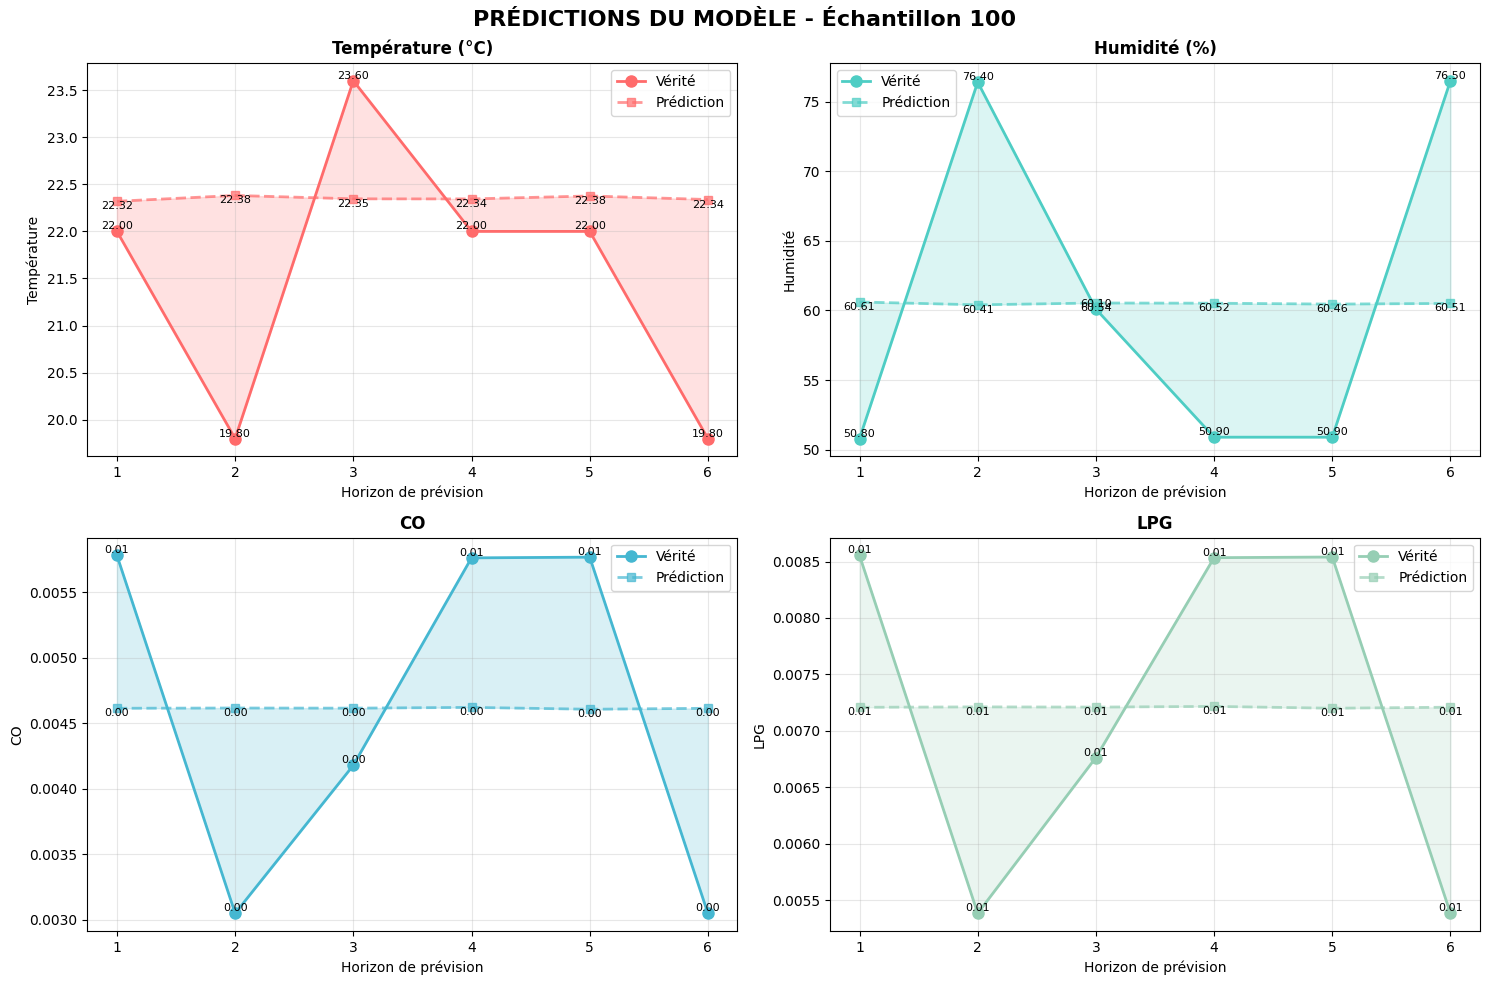


7. 🧪 TEST DE PERFORMANCE SUR TOUT LE DATASET...
   🔄 Calcul des métriques complètes...
   ⏱️  Temps d'évaluation: 29.85 secondes
   📉 Loss sur le test: 0.010666
   🔄 Génération des prédictions complètes...

   🌍 MÉTRIQUES GLOBALES SUR LE TEST:
   📏 MAE global:  3.0092
   📐 RMSE global: 5.6477

   📊 MAE par variable (global):
   • Température (°C): 2.3857
   • Humidité (%): 9.6487
   • CO: 0.0011
   • LPG: 0.0012

8. 📱 TEST TENSORFLOW LITE...
   ❌ Erreur TFLite: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 1 (FlexTensorListReserve) failed to prepare.

🎉 TESTS TERMINÉS - RÉSUMÉ

📊 PERFORMANCES DU MODÈLE:
   • MAE global:  3.0092
   • RMSE global: 5.6477
   • Loss test:   0.010666

⚡ PERFORMANCES 

c:\Users\Macky\Documents\Projet_St\Classification_d'images\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [66]:
# =============================================
# TEST COMPLET DU MODÈLE SAUVEGARDÉ
# =============================================

print("🧪 DÉBUT DES TESTS DU MODÈLE SAUVEGARDÉ")
print("="*60)

# 1. CHARGEMENT DU MODÈLE
print("\n1. 📥 CHARGEMENT DU MODÈLE...")
try:
    # Trouver automatiquement le meilleur modèle sauvegardé
    model_files = [f for f in os.listdir(MODEL_DIR) if f.startswith('BEST_') and f.endswith('.keras')]
    if not model_files:
        # Si pas de BEST_, chercher le modèle final
        model_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.keras')]
    
    if model_files:
        model_file = sorted(model_files)[-1]  # Prendre le plus récent
        MODEL_TEST_PATH = str(MODEL_DIR / model_file)
        print(f"   📁 Modèle trouvé: {model_file}")
    else:
        MODEL_TEST_PATH = BEST_FINAL_MODEL_PATH  # Utiliser le chemin connu
    
    # Chargement
    model = keras.models.load_model(MODEL_TEST_PATH)
    print(f"   ✅ Modèle chargé avec succès: {MODEL_TEST_PATH}")
    print(f"   📊 Architecture: {model.summary()}")
    
except Exception as e:
    print(f"   ❌ Erreur lors du chargement: {e}")
    # Charger le modèle depuis la variable si disponible
    if 'final_model' in locals():
        model = final_model
        print("   ✅ Utilisation du modèle en mémoire")
    else:
        raise

# 2. TEST DE PRÉDICTION SUR UN ÉCHANTILLON
print("\n2. 🔍 TEST DE PRÉDICTION SUR UN ÉCHANTILLON...")

# Prendre un échantillon de test
sample_idx = 100  # Vous pouvez changer cet index
sample_input = X_test[sample_idx:sample_idx+1]
sample_true = Y_test[sample_idx:sample_idx+1]

print(f"   📐 Forme de l'input: {sample_input.shape}")
print(f"   📐 Forme de la cible: {sample_true.shape}")

# Prédiction
start_time = time.time()
sample_pred = model.predict(sample_input, verbose=0)
inference_time = time.time() - start_time

print(f"   ⚡ Temps d'inférence: {inference_time*1000:.2f} ms")
print(f"   📐 Forme de la prédiction: {sample_pred.shape}")

# 3. RECONSTRUCTION DES DONNÉES
print("\n3. 🔄 RECONSTRUCTION DES DONNÉES...")

# Reshape pour avoir [samples, horizon, 4]
sample_pred_reshaped = sample_pred.reshape(-1, FORECAST_HORIZON, 4)
sample_true_reshaped = sample_true.reshape(-1, FORECAST_HORIZON, 4)

# Inverse scaling
sample_pred_inv = scaler_y.inverse_transform(
    sample_pred_reshaped.reshape(-1, 4)
).reshape(-1, FORECAST_HORIZON, 4)

sample_true_inv = scaler_y.inverse_transform(
    sample_true_reshaped.reshape(-1, 4)
).reshape(-1, FORECAST_HORIZON, 4)

print(f"   📊 Données reconstruites:")
print(f"   • Prédictions shape: {sample_pred_inv.shape}")
print(f"   • Vérités shape: {sample_true_inv.shape}")

# 4. AFFICHAGE DES RÉSULTATS DÉTAILLÉS
print("\n4. 📊 RÉSULTATS DÉTAILLÉS POUR L'ÉCHANTILLON:")

# Pour chaque variable
variables = ['Température (°C)', 'Humidité (%)', 'CO', 'LPG']
for var_idx, var_name in enumerate(variables):
    print(f"\n   🔬 {var_name}:")
    print("   Horizon | Vérité      | Prédiction   | Erreur       | Erreur %")
    print("   " + "-"*55)
    
    for step in range(FORECAST_HORIZON):
        true_val = sample_true_inv[0, step, var_idx]
        pred_val = sample_pred_inv[0, step, var_idx]
        error = true_val - pred_val
        error_pct = (abs(error) / (abs(true_val) + 1e-8)) * 100
        
        print(f"   {step+1:^7} | {true_val:11.4f} | {pred_val:12.4f} | {error:12.4f} | {error_pct:8.2f}%")

# 5. CALCUL DES MÉTRIQUES SUR L'ÉCHANTILLON
print("\n5. 📈 MÉTRIQUES SUR L'ÉCHANTILLON TESTÉ:")

# MAE et RMSE pour cet échantillon
mae_sample = np.mean(np.abs(sample_true_inv - sample_pred_inv))
rmse_sample = np.sqrt(np.mean((sample_true_inv - sample_pred_inv)**2))

print(f"   📏 MAE:  {mae_sample:.4f}")
print(f"   📐 RMSE: {rmse_sample:.4f}")

# Métriques par variable
print(f"\n   📊 MAE par variable:")
for var_idx, var_name in enumerate(variables):
    mae_var = np.mean(np.abs(sample_true_inv[0, :, var_idx] - sample_pred_inv[0, :, var_idx]))
    print(f"   • {var_name}: {mae_var:.4f}")

# 6. VISUALISATION DES PRÉDICTIONS
print("\n6. 📊 VISUALISATION DES PRÉDICTIONS...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'PRÉDICTIONS DU MODÈLE - Échantillon {sample_idx}', fontsize=16, fontweight='bold')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for var_idx, var_name in enumerate(variables):
    row, col = var_idx // 2, var_idx % 2
    
    # Données
    horizons = range(1, FORECAST_HORIZON + 1)
    true_vals = sample_true_inv[0, :, var_idx]
    pred_vals = sample_pred_inv[0, :, var_idx]
    
    # Graphique
    axes[row, col].plot(horizons, true_vals, 'o-', label='Vérité', color=colors[var_idx], linewidth=2, markersize=8)
    axes[row, col].plot(horizons, pred_vals, 's--', label='Prédiction', color=colors[var_idx], 
                       alpha=0.7, linewidth=2, markersize=6)
    
    # Remplissage d'erreur
    axes[row, col].fill_between(horizons, true_vals, pred_vals, alpha=0.2, color=colors[var_idx])
    
    # Configuration
    axes[row, col].set_title(f'{var_name}', fontweight='bold', fontsize=12)
    axes[row, col].set_xlabel('Horizon de prévision', fontsize=10)
    axes[row, col].set_ylabel(var_name.split(' ')[0], fontsize=10)
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)
    
    # Ajouter les valeurs sur les points
    for i, (true, pred) in enumerate(zip(true_vals, pred_vals)):
        axes[row, col].text(i+1, true, f'{true:.2f}', ha='center', va='bottom', fontsize=8)
        axes[row, col].text(i+1, pred, f'{pred:.2f}', ha='center', va='top', fontsize=8)

plt.tight_layout()
plt.show()

# 7. TEST DE PERFORMANCE SUR TOUT LE DATASET DE TEST
print("\n7. 🧪 TEST DE PERFORMANCE SUR TOUT LE DATASET...")

# Évaluation complète (peut prendre du temps)
print("   🔄 Calcul des métriques complètes...")
start_time = time.time()
test_loss = model.evaluate(X_test, Y_test, batch_size=BATCH_SIZE, verbose=0)
eval_time = time.time() - start_time

print(f"   ⏱️  Temps d'évaluation: {eval_time:.2f} secondes")
print(f"   📉 Loss sur le test: {test_loss:.6f}")

# Prédictions complètes
print("   🔄 Génération des prédictions complètes...")
Y_test_pred_flat = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
Y_test_pred = Y_test_pred_flat.reshape(-1, FORECAST_HORIZON, 4)
Y_test_true = Y_test.reshape(-1, FORECAST_HORIZON, 4)

# Reconstruction
Y_test_pred_inv = scaler_y.inverse_transform(Y_test_pred.reshape(-1, 4)).reshape(-1, FORECAST_HORIZON, 4)
Y_test_true_inv = scaler_y.inverse_transform(Y_test_true.reshape(-1, 4)).reshape(-1, FORECAST_HORIZON, 4)

# Métriques globales
mae_global = np.mean(np.abs(Y_test_true_inv - Y_test_pred_inv))
rmse_global = np.sqrt(np.mean((Y_test_true_inv - Y_test_pred_inv)**2))

print(f"\n   🌍 MÉTRIQUES GLOBALES SUR LE TEST:")
print(f"   📏 MAE global:  {mae_global:.4f}")
print(f"   📐 RMSE global: {rmse_global:.4f}")

print(f"\n   📊 MAE par variable (global):")
mae_per_var_global = np.mean(np.abs(Y_test_true_inv - Y_test_pred_inv), axis=(0, 1))
for var_idx, var_name in enumerate(variables):
    print(f"   • {var_name}: {mae_per_var_global[var_idx]:.4f}")

# 8. TEST TENSORFLOW LITE (pour mobile)
print("\n8. 📱 TEST TENSORFLOW LITE...")

try:
    # Trouver le fichier tflite
    tflite_files = [f for f in os.listdir(MODEL_DIR) if f.endswith('.tflite')]
    if tflite_files:
        tflite_file = sorted(tflite_files)[-1]
        TFLITE_TEST_PATH = str(MODEL_DIR / tflite_file)
    else:
        TFLITE_TEST_PATH = TFLITE_MOBILE_PATH
    
    # Charger l'interpréteur
    interpreter = tf.lite.Interpreter(model_path=TFLITE_TEST_PATH)
    interpreter.allocate_tensors()
    
    # Détails
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"   ✅ TensorFlow Lite chargé: {tflite_file}")
    print(f"   📥 Input: {input_details[0]['shape']} ({input_details[0]['dtype']})")
    print(f"   📤 Output: {output_details[0]['shape']} ({output_details[0]['dtype']})")
    
    # Test de prédiction avec TFLite
    interpreter.set_tensor(input_details[0]['index'], sample_input.astype(np.float32))
    interpreter.invoke()
    tflite_output = interpreter.get_tensor(output_details[0]['index'])
    
    # Comparaison des résultats
    diff = np.mean(np.abs(sample_pred - tflite_output))
    print(f"   🔄 Différence moyenne Keras vs TFLite: {diff:.8f}")
    
    if diff < 1e-4:
        print("   ✅ Résultats identiques entre Keras et TFLite")
    else:
        print("   ⚠️  Légères différences entre Keras et TFLite")
        
except Exception as e:
    print(f"   ❌ Erreur TFLite: {e}")

# 9. RÉSUMÉ FINAL
print("\n" + "="*60)
print("🎉 TESTS TERMINÉS - RÉSUMÉ")
print("="*60)

print(f"\n📊 PERFORMANCES DU MODÈLE:")
print(f"   • MAE global:  {mae_global:.4f}")
print(f"   • RMSE global: {rmse_global:.4f}")
print(f"   • Loss test:   {test_loss:.6f}")

print(f"\n⚡ PERFORMANCES TECHNIQUES:")
print(f"   • Temps inférence: {inference_time*1000:.2f} ms")
print(f"   • Temps évaluation: {eval_time:.2f} s")

print(f"\n📁 FICHIERS DISPONIBLES:")
model_dir_files = [f for f in os.listdir(MODEL_DIR) if f.endswith(('.keras', '.tflite', '.json'))]
for file in sorted(model_dir_files):
    file_path = MODEL_DIR / file
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"   • {file} ({size_mb:.2f} MB)")

print(f"\n✅ Le modèle est prêt pour le déploiement sur téléphone!")
print(f"📱 Utilisez le fichier: {[f for f in model_dir_files if f.endswith('.tflite')][0]}")